# Previsione dei prezzi immobiliari — Pipeline ML end-to-end
### Dataset: *Ames Housing* (2930 abitazioni, 80 feature + target `SalePrice`)

Questo notebook implementa una pipeline di Machine Learning **modulare e riproducibile**
per la previsione del prezzo di vendita di immobili residenziali nella città di Ames (Iowa),
a partire dalle loro caratteristiche fisiche, qualitative e di contesto.

L'intero lavoro è organizzato in fasi indipendenti e documentate, seguendo le buone pratiche
di sviluppo ML (separazione delle responsabilità, funzioni riutilizzabili, configurazione
centralizzata, controllo della casualità).

---

## Indice del progetto

| Fase | Contenuto |
|------|-----------|
| **1. Caricamento e comprensione** | funzione di caricamento, struttura, tipi di dato, distribuzioni iniziali |
| **2. Data wrangling avanzato** | gestione missing per natura, correzione errori, rimozione outlier |
| **2-EDA. Analisi esplorativa** | correlazioni con il prezzo, relazioni feature–target, pattern delle categoriche |
| **3. Feature engineering & preprocessing** | encoding categoriche, scaling condizionato, feature derivate |
| **4. Modellazione & ottimizzazione** | 3 modelli a confronto, tuning iperparametri, K-fold CV |
| **5/finale. Valutazione e interpretazione** | stima non distorta sul test set, analisi dei residui, tabella comparativa, feature importance, pro e contro |

*Tutte le fasi sono implementate ed eseguite. Subito sotto, una sintesi in linguaggio semplice;
più in basso, le sezioni tecniche con il codice.*

### Fase 2-EDA — Abbiamo "esplorato" i dati per scoprire cosa conta (in parole semplici)

Prima di costruire qualsiasi modello conviene *guardare* i dati e farsi qualche domanda:
**quali caratteristiche di una casa influenzano davvero il prezzo?** Questa fase è come la visita
di un perito che, prima di stimare, osserva quali fattori fanno la differenza.

Abbiamo scoperto, numeri alla mano, che il prezzo dipende soprattutto da poche cose intuitive:
la **qualità complessiva** dei materiali e delle finiture (di gran lunga il fattore più forte), la
**superficie abitabile**, la dimensione del **seminterrato** e del **garage**, e l'**anno di
costruzione**. Abbiamo anche visto che alcune caratteristiche "si somigliano" tra loro — per
esempio quante auto entrano in garage e quanti metri quadri ha il garage raccontano la stessa cosa
— un'informazione utile per non appesantire inutilmente il modello.

Infine abbiamo osservato come il prezzo cambia al variare delle caratteristiche "a parole" (come il
quartiere o il livello di qualità): salendo di livello di qualità, il prezzo cresce in modo
regolare e marcato. Tutte queste osservazioni ci hanno guidato nelle scelte della fase successiva,
suggerendoci quali informazioni valeva la pena creare e combinare.

---

### Fase 3 — Abbiamo "preparato" i dati per il modello (in parole semplici)

Un modello di Machine Learning non "capisce" parole come *Eccellente* o *quartiere NAmes*,
e fatica se i numeri hanno scale molto diverse fra loro (i metri quadri sono migliaia, il
numero di bagni è 1 o 2). In questa fase abbiamo quindi **tradotto e messo in ordine** i dati,
e ne abbiamo creati di nuovi più utili. Tre cose, in concreto:

* **Abbiamo tradotto le parole in numeri (encoding).** Per le qualità che hanno un ordine
  naturale — *Scarsa < Discreta < Buona < Ottima* — abbiamo usato una scala crescente, così
  il modello capisce che "Ottima" vale più di "Buona". Per le categorie senza ordine — come il
  nome del quartiere — abbiamo creato invece tante caselle "sì/no" (una per quartiere), per non
  inventare gerarchie che non esistono.
* **Abbiamo messo i numeri sulla stessa scala (scaling "condizionato").** Abbiamo uniformato
  le grandezze così che nessuna prevalga solo perché espressa in numeri più grandi. Dove un
  valore era molto "sbilanciato" (poche case enormi rispetto a tante normali) abbiamo prima
  applicato una compressione matematica che lo rende più equilibrato — da qui "condizionato":
  l'aggiustamento si attiva *solo* dove serve.
* **Abbiamo inventato informazioni nuove e più parlanti (feature derivate).** Invece di lasciare
  al modello il compito di dedurle, gliele forniamo già pronte: l'**età della casa** (dagli anni
  di costruzione e vendita), la **superficie totale** sommando i vari piani, i **bagni totali**,
  lo **spazio per stanza**, e un **punteggio di qualità complessivo**. Sono spesso gli indizi
  più forti sul prezzo.

Tutto questo è stato costruito come una "**catena di montaggio**" automatica e riutilizzabile:
i dati grezzi entrano da un lato ed escono pronti per il modello dall'altro, sempre allo stesso
modo. E, come prima, la catena "impara" le sue regole **solo dai dati di allenamento**, per
garantire una valutazione onesta.

---

### Fase 4 — Abbiamo "messo alla prova" diversi modelli (in parole semplici)

Adesso che i dati sono puliti e ben preparati, possiamo finalmente costruire il "cervello"
che prevede i prezzi. Ma quale tipo di cervello funziona meglio? Non c'è una risposta unica a
priori, quindi ne abbiamo **provati tre diversi** e li abbiamo messi in gara:

* un modello **semplice e lineare**, che cerca una formula diretta "più grande/più nuova = più
  cara". È il nostro punto di riferimento (la *baseline*): se i modelli complessi non lo battono,
  tanto vale tenere quello semplice.
* una **"foresta" di alberi decisionali** (*Random Forest*): centinaia di piccole regole del tipo
  "se il quartiere è X e la superficie supera Y, allora…", la cui media dà una stima robusta.
* un modello di **boosting** (*XGBoost*), oggi fra i più potenti: costruisce gli alberi uno dopo
  l'altro, e ognuno impara a correggere gli errori del precedente.

**Come decidiamo chi vince, in modo onesto?** Non basta provare il modello una volta sola: si
rischia di essere fortunati. Usiamo allora la **"validazione incrociata"** (*K-fold*): dividiamo
le case in 5 gruppi, alleniamo il modello su 4 e lo testiamo sul quinto, ruotando i gruppi.
Così ogni casa viene usata sia per imparare sia per essere verificata, e otteniamo un voto medio
molto più affidabile.

Infine abbiamo fatto la **"messa a punto fine" (tuning)**: ogni modello ha delle "manopole"
(quante regole, quanto profonde, quanto deve imparare in fretta…). Le abbiamo regolate
automaticamente provando molte combinazioni e tenendo la migliore. Il risultato è una classifica
chiara di quale modello prevede i prezzi con l'errore più piccolo.

---

### Fase 5/finale — L'esame finale e l'interpretazione del modello (in parole semplici)

Durante tutta la costruzione abbiamo messo da parte, fin dall'inizio, un gruppo di case
(circa il 20%, **586 abitazioni**) che il modello **non ha mai visto**: né per imparare, né per
essere regolato. È come tenere nascoste alcune domande fino al giorno dell'esame.

In questa fase tiriamo fuori quelle case e chiediamo al modello di prevederne il prezzo "a freddo".
È la prova del nove: se va bene anche su case mai viste, allora **non ha semplicemente imparato a
memoria** i dati di allenamento, ma ha colto regole che valgono in generale. Confrontiamo l'errore
su questo "esame finale" con quello stimato durante l'allenamento: se sono simili, il modello è
solido e affidabile.

Infine guardiamo gli **errori residui** — di quanto sbaglia e in che direzione — per assicurarci
che non ci siano problemi sistematici (ad esempio sottostimare sempre le case più costose). È il
controllo di qualità che dà fiducia prima di usare davvero il modello.

---

### Fase 5/finale (continua) — Cosa fa il modello e quale conviene

Avere un modello che indovina i prezzi non basta: vogliamo anche capire **perché** decide così
e **quale tipo di modello conviene davvero usare**. Tre cose, in concreto:

* **Una pagella a confronto.** Abbiamo messo fianco a fianco il modello semplice (lineare) e
  quello più sofisticato ad alberi (XGBoost), con i loro voti. Così si vede a colpo d'occhio chi
  prevede meglio e di quanto.
* **Cosa guarda di più il modello.** Abbiamo chiesto al modello ad alberi (XGBoost) quali
  caratteristiche pesano di più nelle sue decisioni. Senza sorprese, contano soprattutto la **qualità
  complessiva** della casa, la **superficie totale**, il **garage** e la presenza di
  **aria condizionata**. È rassicurante: il modello ha "imparato" le stesse cose che guarderebbe
  un agente immobiliare esperto. Da notare che molte delle informazioni che *noi avevamo costruito*
  nella fase di preparazione (come "qualità per superficie") risultano fra le più importanti:
  segno che quel lavoro è servito.
* **Pro e contro di ciascun modello.** Non esiste il modello perfetto in assoluto: quello semplice
  è velocissimo e facile da spiegare ma coglie meno le sfumature; quello ad alberi è più preciso e
  cattura relazioni complesse, ma è più pesante e meno trasparente. Abbiamo riassunto questi
  compromessi per aiutare a scegliere in base alle esigenze (velocità, precisione, chiarezza).

In sintesi: non solo sappiamo *quanto* il modello è bravo, ma anche *perché* lo è e *quando*
conviene preferirne uno all'altro.

---

## 1.0 Setup e configurazione

Tutta la configurazione (percorsi, seed, costanti) è centralizzata in un unico punto,
così da rendere il notebook riproducibile e facile da adattare ad altri ambienti.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configurazione centralizzata -------------------------------------------
RANDOM_STATE = 42                 # seed unico per tutta la pipeline -> riproducibilità
DATA_PATH = Path("AmesHousing.csv")
TARGET = "SalePrice"
ID_COLS = ["Order", "PID"]        # identificatori: non predittivi, da escludere dal modello

# --- Impostazioni di visualizzazione ----------------------------------------
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
warnings.filterwarnings("ignore", category=FutureWarning)

np.random.seed(RANDOM_STATE)
print("Ambiente configurato. Seed =", RANDOM_STATE)

Ambiente configurato. Seed = 42


## 1.1 Funzione di caricamento dei dati

Incapsuliamo il caricamento in una funzione dedicata invece di chiamare `pd.read_csv`
sparpagliato nel notebook. Questo garantisce che **ogni volta** i dati vengano letti
nello stesso modo, e ci permette di centralizzare alcune scelte importanti.

**Scelta di progetto sui valori mancanti.**
Nel dataset Ames la stringa `NA` ha un duplice significato e va trattata con attenzione:

* per molte feature categoriche significa **"caratteristica assente"** e *non* un dato mancante.
  Esempio: `Pool QC = NA` indica *"l'abitazione non ha piscina"*, `Garage Type = NA` indica
  *"nessun garage"*. Sono informazioni valide, non buchi nei dati.
* per poche feature numeriche (es. `Lot Frontage`) è invece un valore realmente non rilevato.

Per non perdere questa distinzione, **disattiviamo la conversione automatica di `NA` in `NaN`**
in fase di lettura (`keep_default_na=False`) e gestiremo i mancanti in modo esplicito e
consapevole nella fase di pre-processing. La funzione restituisce comunque i `NaN` solo dove
hanno senso semantico.

In [2]:
def load_data(path: Path = DATA_PATH, *, raw_na: bool = True) -> pd.DataFrame:
    """Carica il dataset Ames Housing in modo riproducibile.

    Parameters
    ----------
    path : Path
        Percorso del file CSV.
    raw_na : bool, default True
        Se True conserva le stringhe "NA" originali (significato semantico:
        "feature assente"). Se False lascia che pandas le converta in NaN.

    Returns
    -------
    pd.DataFrame
        Il dataset grezzo, con le sole pulizie strutturali sicure
        (rimozione spazi nei nomi colonna, trim delle stringhe).
    """
    if not Path(path).exists():
        raise FileNotFoundError(f"File non trovato: {path}")

    # keep_default_na=False -> "NA" resta stringa, non diventa NaN automaticamente.
    # na_values=[""] -> solo le celle realmente vuote diventano NaN.
    read_kwargs = dict(keep_default_na=False, na_values=[""]) if raw_na else {}
    df = pd.read_csv(path, **read_kwargs)

    # Pulizie strutturali sicure (non alterano i valori, solo la forma):
    df.columns = df.columns.str.strip()                       # nomi colonna senza spazi
    obj_cols = df.select_dtypes(include="object").columns
    df[obj_cols] = df[obj_cols].apply(lambda s: s.str.strip())  # trim valori testuali

    return df


# Caricamento
df = load_data()
print(f"Dataset caricato correttamente: {df.shape[0]} righe x {df.shape[1]} colonne")
df.head()

Dataset caricato correttamente: 2930 righe x 82 colonne


/tmp/ipykernel_546/3910135501.py:28: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = df.select_dtypes(include="object").columns


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NA,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NA,NA,NA,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NA,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NA,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NA,MnPrv,NA,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NA,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NA,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NA,NA,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NA,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,None,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NA,NA,NA,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NA,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NA,MnPrv,NA,0,3,2010,WD,Normal,189900


## 1.2 Struttura del dataset: dimensioni e tipi di dato

Prima di qualsiasi analisi statistica osserviamo la "forma" del dataset: quante
osservazioni, quante variabili, di che tipo. Costruiamo una funzione di riepilogo
riutilizzabile.

In [3]:
def dataset_overview(df: pd.DataFrame) -> None:
    """Stampa un riepilogo strutturale ad alto livello del DataFrame."""
    n_rows, n_cols = df.shape
    num_cols = df.select_dtypes(include=np.number).columns
    cat_cols = df.select_dtypes(include="object").columns
    mem_mb = df.memory_usage(deep=True).sum() / 1024**2

    print("=" * 55)
    print(f"{'Osservazioni (righe)':<35}{n_rows:>20}")
    print(f"{'Variabili (colonne)':<35}{n_cols:>20}")
    print(f"{'  - numeriche':<35}{len(num_cols):>20}")
    print(f"{'  - categoriche / testuali':<35}{len(cat_cols):>20}")
    print(f"{'Variabile target':<35}{TARGET:>20}")
    print(f"{'Occupazione in memoria (MB)':<35}{mem_mb:>20.2f}")
    print("=" * 55)


dataset_overview(df)

Osservazioni (righe)                               2930
Variabili (colonne)                                  82
  - numeriche                                        39
  - categoriche / testuali                           43
Variabile target                              SalePrice
Occupazione in memoria (MB)                        7.19


/tmp/ipykernel_546/3065432916.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


Osserviamo la ripartizione esatta dei tipi e isoliamo le colonne identificative,
che andranno escluse dalla modellazione perché non portano informazione predittiva
(`Order` è un semplice indice progressivo, `PID` è il codice catastale dell'immobile).

In [4]:
print("Conteggio per tipo di dato:")
print(df.dtypes.value_counts().to_string())

print("\nColonne identificative (da escludere dal modello):")
for c in ID_COLS:
    print(f"  - {c}: {df[c].nunique()} valori unici su {len(df)} righe")

Conteggio per tipo di dato:
str        43
int64      28
float64    11

Colonne identificative (da escludere dal modello):
  - Order: 2930 valori unici su 2930 righe
  - PID: 2930 valori unici su 2930 righe


## 1.3 Dizionario dei dati (profilo per colonna)

Con 80 variabili, scorrere le colonne a mano è inefficiente. Costruiamo un
**dizionario dei dati** generato automaticamente: per ogni colonna riporta tipo,
numero di valori distinti, percentuale di mancanti e alcuni valori di esempio.
È uno strumento di lavoro che riuseremo per decidere le strategie di pre-processing.

In [5]:
def build_data_dictionary(df: pd.DataFrame) -> pd.DataFrame:
    """Genera un profilo sintetico per ogni colonna del DataFrame.

    Per ogni variabile riporta: tipo, numero di valori distinti,
    conteggio e percentuale di valori mancanti (NaN reali) e
    un campione di valori osservati.
    """
    profile = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "n_unique": df.nunique(dropna=True),
        "n_missing": df.isna().sum(),
    })
    profile["pct_missing"] = (profile["n_missing"] / len(df) * 100).round(2)
    profile["sample_values"] = [
        ", ".join(map(str, df[c].dropna().unique()[:4]))
        for c in df.columns
    ]
    return profile.sort_values("pct_missing", ascending=False)


data_dict = build_data_dictionary(df)
print(f"Dizionario dati: {data_dict.shape[0]} variabili profilate.")
data_dict.head(20)

Dizionario dati: 82 variabili profilate.


,dtype,n_unique,n_missing,pct_missing,sample_values
Lot Frontage,float64,128,490,16.72,"141.0, 80.0, 81.0, 93.0"
Garage Yr Blt,float64,103,159,5.43,"1960.0, 1961.0, 1958.0, 1968.0"
Mas Vnr Area,float64,445,23,0.78,"112.0, 0.0, 108.0, 20.0"
Mas Vnr Type,str,5,23,0.78,"Stone, None, BrkFace, BrkCmn"
Bsmt Exposure,str,5,4,0.14,"Gd, No, Mn, Av"
Bsmt Full Bath,float64,4,2,0.07,"1.0, 0.0, 2.0, 3.0"
BsmtFin Type 2,str,7,2,0.07,"Unf, LwQ, BLQ, Rec"
Garage Finish,str,4,2,0.07,"Fin, Unf, RFn, NA"
Bsmt Half Bath,float64,3,2,0.07,"0.0, 1.0, 2.0"
BsmtFin SF 2,float64,274,1,0.03,"0.0, 144.0, 1120.0, 163.0"


## 1.4 Valori mancanti: distinguere "assente" da "non rilevato"

Come anticipato, qui sta una delle insidie principali del dataset Ames. Quantifichiamo
i `NaN` *reali* (celle vuote nel CSV) e mostriamo separatamente i casi in cui la stringa
`"NA"` è invece un valore informativo ("feature assente").

In [6]:
# 1) NaN reali (celle vuote) -- questi sono i veri mancanti da gestire
real_missing = df.isna().sum()
real_missing = real_missing[real_missing > 0].sort_values(ascending=False)

print(f"Colonne con NaN REALI (celle vuote): {len(real_missing)}")
print(real_missing.to_string())

# 2) Stringa "NA" semantica ("feature assente"): conteggio per colonna
na_semantic = (df == "NA").sum()
na_semantic = na_semantic[na_semantic > 0].sort_values(ascending=False)

print(f"\nColonne dove \"NA\" significa FEATURE ASSENTE (non un dato mancante): {len(na_semantic)}")
print(na_semantic.head(12).to_string())

Colonne con NaN REALI (celle vuote): 21
Lot Frontage      490
Garage Yr Blt     159
Mas Vnr Type       23
Mas Vnr Area       23
Bsmt Exposure       4
Garage Finish       2
Bsmt Half Bath      2
Bsmt Full Bath      2
BsmtFin Type 2      2
Bsmt Cond           1
Bsmt Qual           1
BsmtFin Type 1      1
BsmtFin SF 1        1
Electrical          1
Total Bsmt SF       1
Bsmt Unf SF         1
BsmtFin SF 2        1
Garage Cars         1
Garage Area         1
Garage Qual         1
Garage Cond         1

Colonne dove "NA" significa FEATURE ASSENTE (non un dato mancante): 14
Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Fireplace Qu      1422
Garage Qual        158
Garage Cond        158
Garage Finish      157
Garage Type        157
BsmtFin Type 2      79
Bsmt Qual           79
BsmtFin Type 1      79


**Lettura del risultato.** Le colonne con `"NA"` semantico (`Pool QC`, `Misc Feature`,
`Alley`, `Fence`, `Garage *`, `Bsmt *`, ...) descrivono la **mancanza di una dotazione**:
andranno trasformate in una categoria esplicita (es. `"None"`) e *non* imputate.
I pochi `NaN` reali (principalmente `Lot Frontage`, `Mas Vnr Area`, `Garage Yr Blt`)
sono invece valori non rilevati, da imputare nella fase di pre-processing.
Distinguere i due casi evita di introdurre bias e di perdere informazione.

## 1.5 Distribuzione della variabile target (`SalePrice`)

La comprensione del target è essenziale: la sua distribuzione condiziona la scelta
della metrica, l'eventuale trasformazione e l'interpretazione dei risultati.

In [7]:
price = df[TARGET]

stats = {
    "Conteggio": price.count(),
    "Media": price.mean(),
    "Mediana": price.median(),
    "Dev. standard": price.std(),
    "Minimo": price.min(),
    "Massimo": price.max(),
    "Asimmetria (skew)": price.skew(),
    "Curtosi": price.kurt(),
}
for k, v in stats.items():
    print(f"{k:<20}{v:>15,.2f}")

Conteggio                  2,930.00
Media                    180,796.06
Mediana                  160,000.00
Dev. standard             79,886.69
Minimo                    12,789.00
Massimo                  755,000.00
Asimmetria (skew)              1.74
Curtosi                        5.12


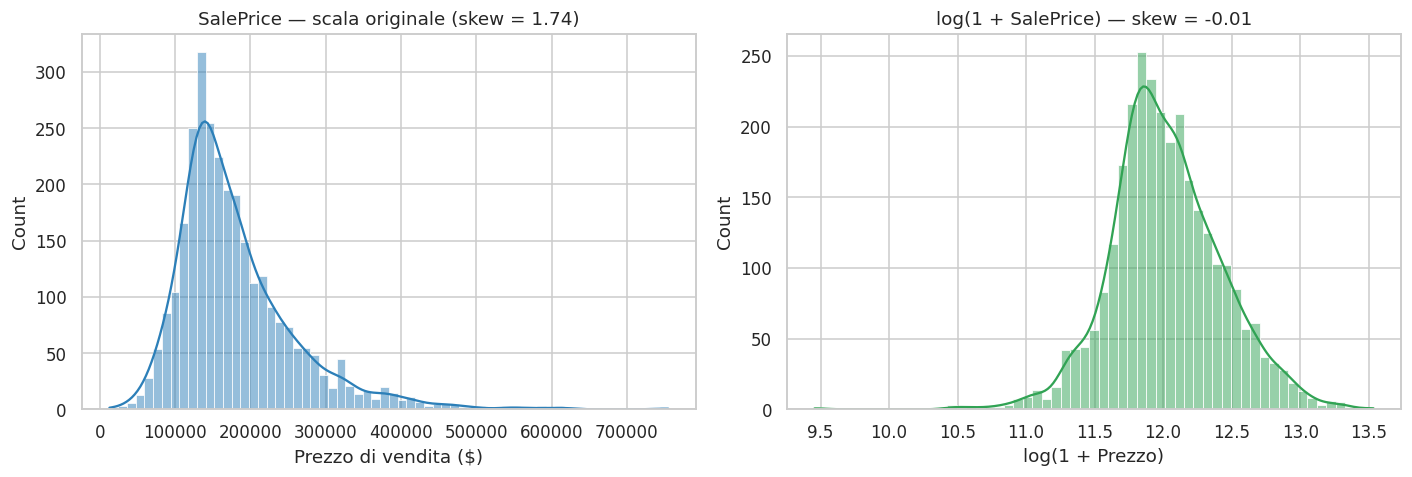

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Distribuzione originale: chiaramente asimmetrica a destra
sns.histplot(price, kde=True, ax=axes[0], color="#2c7fb8")
axes[0].set_title(f"SalePrice — scala originale (skew = {price.skew():.2f})")
axes[0].set_xlabel("Prezzo di vendita ($)")

# Distribuzione log: si avvicina molto a una normale
sns.histplot(np.log1p(price), kde=True, ax=axes[1], color="#31a354")
axes[1].set_title(f"log(1 + SalePrice) — skew = {np.log1p(price).skew():.2f}")
axes[1].set_xlabel("log(1 + Prezzo)")

plt.tight_layout()
plt.show()

**Conclusione operativa.** `SalePrice` è fortemente asimmetrico a destra
(skew ≈ 1.74): poche abitazioni molto costose allungano la coda. La trasformazione
logaritmica `log(1 + SalePrice)` rende la distribuzione quasi simmetrica (skew ≈ 0.04).
Per questo, nelle fasi successive, **modelleremo il logaritmo del prezzo** e valuteremo
con la metrica RMSE sul log — coerente con la metrica ufficiale della competizione Ames
e meno sensibile agli immobili di valore estremo.

## 1.6 Distribuzioni iniziali delle feature

Uno sguardo d'insieme alle distribuzioni: alcune variabili numeriche chiave e la
cardinalità delle variabili categoriche. Serve a farsi un'idea di scala, asimmetrie
e varietà prima dell'EDA approfondita (Fase 2).

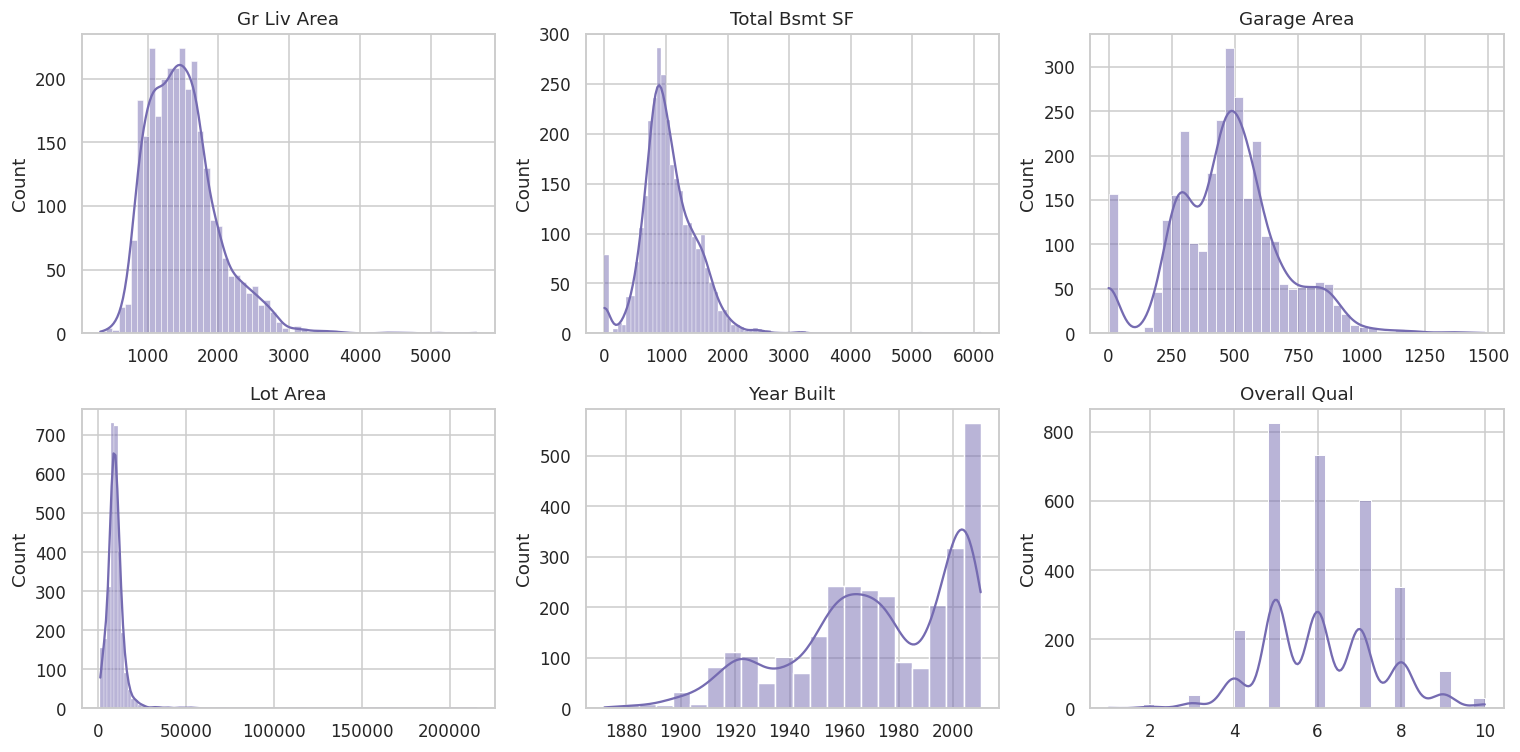

In [9]:
# Alcune feature numeriche fra le più rilevanti per il prezzo di un immobile
key_numeric = ["Gr Liv Area", "Total Bsmt SF", "Garage Area",
               "Lot Area", "Year Built", "Overall Qual"]
key_numeric = [c for c in key_numeric if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), key_numeric):
    sns.histplot(df[col], kde=True, ax=ax, color="#756bb1")
    ax.set_title(col)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

In [10]:
# Cardinalità delle variabili categoriche: quante categorie ha ciascuna?
cat_cols = df.select_dtypes(include="object").columns
cardinality = df[cat_cols].nunique().sort_values(ascending=False)

print("Variabili categoriche per numero di categorie distinte:")
print(cardinality.to_string())
print(f"\nTotale variabili categoriche: {len(cat_cols)}")
print(f"Cardinalità media: {cardinality.mean():.1f} | massima: {cardinality.max()} "
      f"({cardinality.idxmax()})")

Variabili categoriche per numero di categorie distinte:
Neighborhood      28
Exterior 2nd      17
Exterior 1st      16
Sale Type         10
Condition 1        9
House Style        8
Functional         8
Roof Matl          8
Condition 2        8
MS Zoning          7
BsmtFin Type 1     7
Garage Type        7
BsmtFin Type 2     7
Sale Condition     6
Misc Feature       6
Fireplace Qu       6
Bsmt Cond          6
Roof Style         6
Garage Cond        6
Garage Qual        6
Heating            6
Bsmt Qual          6
Foundation         6
Bldg Type          5
Bsmt Exposure      5
Lot Config         5
Heating QC         5
Fence              5
Pool QC            5
Kitchen Qual       5
Electrical         5
Mas Vnr Type       5
Exter Cond         5
Land Contour       4
Lot Shape          4
Exter Qual         4
Garage Finish      4
Alley              3
Utilities          3
Paved Drive        3
Land Slope         3
Street             2
Central Air        2

Totale variabili categoriche: 43
Cardina

/tmp/ipykernel_546/3734585145.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


**Sintesi della Fase 1.**

* Il dataset conta **2930 osservazioni** e **82 colonne**: 80 feature predittive,
  1 target (`SalePrice`) e gli identificatori `Order`/`PID` da scartare.
* Le variabili si dividono in **~39 numeriche** e **~43 categoriche**: la pipeline
  dovrà trattare i due gruppi in modo differente (encoding vs scaling).
* I "valori mancanti" sono di **due nature diverse**: assenza semantica di una dotazione
  (da codificare come categoria) e valori realmente non rilevati (da imputare).
* Il **target è asimmetrico**: lavoreremo sul suo logaritmo.

Con questa comprensione strutturale possiamo procedere, nella fase successiva,
all'analisi esplorativa delle relazioni fra le feature e il prezzo.

---
# Fase 2 — Data Wrangling avanzato

Sulla base della comprensione strutturale della Fase 1, ripuliamo il dataset gestendo
**valori mancanti** e **outlier**. Adottiamo un principio guida fondamentale per evitare
il *data leakage*:

> Distinguiamo i **fix deterministici** (che non usano statistiche fra le righe né il target)
> dalle **imputazioni statistiche** (che stimano un valore da altre osservazioni).
> I primi sono sicuri da applicare all'intero dataset; le seconde, in una pipeline rigorosa,
> vanno *apprese solo sul training set*. Progettiamo le funzioni per essere coerenti con
> questa distinzione e riutilizzabili nella pipeline finale (Fase 3–4).


## 2.1 Mappa ragionata dei valori mancanti

Dall'analisi della Fase 1 i mancanti ricadono in **tre categorie**, ciascuna con una
strategia diversa. Le codifichiamo esplicitamente come configurazione, così la logica
è leggibile e verificabile.

In [11]:
# --- Categoria A: "NA" categorico = FEATURE ASSENTE -> diventa categoria "None" ----
# (es. Pool QC=NA -> nessuna piscina). Fix deterministico, nessun leakage.
SEMANTIC_NONE_CAT = [
    "Alley", "Bsmt Qual", "Bsmt Cond", "Bsmt Exposure",
    "BsmtFin Type 1", "BsmtFin Type 2", "Fireplace Qu",
    "Garage Type", "Garage Finish", "Garage Qual", "Garage Cond",
    "Pool QC", "Fence", "Misc Feature", "Mas Vnr Type",
]

# --- Categoria B: numeriche STRUTTURALMENTE assenti -> 0 ---------------------------
# (nessun garage/seminterrato => area, bagni, posti auto = 0). Deterministico.
STRUCTURAL_ZERO_NUM = [
    "Mas Vnr Area", "BsmtFin SF 1", "BsmtFin SF 2", "Bsmt Unf SF",
    "Total Bsmt SF", "Bsmt Full Bath", "Bsmt Half Bath",
    "Garage Cars", "Garage Area",
]

# --- Categoria C: mancanti VERI da imputare statisticamente ------------------------
#   Lot Frontage -> mediana per quartiere (Neighborhood): cattura la regolarità urbana
#   Electrical   -> moda (1 solo mancante)
#   Garage Yr Blt-> trattamento dedicato (vedi sotto)
STAT_IMPUTE = ["Lot Frontage", "Electrical", "Garage Yr Blt"]

print("Categoria A (NA semantico -> 'None'):", len(SEMANTIC_NONE_CAT), "colonne")
print("Categoria B (strutturale -> 0):     ", len(STRUCTURAL_ZERO_NUM), "colonne")
print("Categoria C (imputazione statistica):", len(STAT_IMPUTE), "colonne")

Categoria A (NA semantico -> 'None'): 15 colonne
Categoria B (strutturale -> 0):      9 colonne
Categoria C (imputazione statistica): 3 colonne


## 2.2 Fix deterministici (sicuri, senza leakage)

Questi interventi non dipendono da statistiche calcolate su altre righe né dal target:
sono semplici regole di codifica e correzioni di errori evidenti. Sono quindi sicuri
da applicare all'intero dataset.

In [12]:
def fix_deterministic(df: pd.DataFrame) -> pd.DataFrame:
    """Applica le correzioni deterministiche dei mancanti e degli errori noti.

    - Categoria A: "NA"/NaN nelle categoriche elencate -> "None" (feature assente)
    - Categoria B: NaN nelle numeriche strutturali -> 0 (dotazione assente)
    - Correzione errori di data entry noti (es. Garage Yr Blt = 2207 -> 2007)
    Non introduce data leakage: nessuna statistica fra righe, nessun uso del target.
    """
    df = df.copy()

    # Categoria A: la stringa "NA" e gli eventuali NaN diventano la categoria "None"
    for col in SEMANTIC_NONE_CAT:
        df[col] = df[col].replace("NA", "None").fillna("None")

    # Categoria B: le numeriche strutturali mancanti -> 0
    for col in STRUCTURAL_ZERO_NUM:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

    # Correzione errore noto: anno garage 2207 (impossibile) -> 2007 (refuso evidente)
    if "Garage Yr Blt" in df.columns:
        gyb = pd.to_numeric(df["Garage Yr Blt"], errors="coerce")
        df["Garage Yr Blt"] = gyb.where(gyb <= 2010, 2007)

    return df


df_clean = fix_deterministic(df)
print("Fix deterministici applicati.")
print("NaN residui dopo Categoria A+B:", int(df_clean[SEMANTIC_NONE_CAT + STRUCTURAL_ZERO_NUM].isna().sum().sum()))

Fix deterministici applicati.
NaN residui dopo Categoria A+B: 0


## 2.3 Imputazione statistica (pipeline-ready)

`Lot Frontage` (490 mancanti) è la metratura del fronte-strada del lotto: è fortemente
legata al **quartiere** (lotti dello stesso isolato hanno fronti simili). La imputiamo
quindi con la **mediana per `Neighborhood`**, molto più accurata della mediana globale.

Poiché questa imputazione *apprende statistiche dai dati*, la incapsuliamo in una funzione
che **separa l'apprendimento (`fit`) dall'applicazione (`transform`)**: i valori vengono
stimati su un set di riferimento (in produzione: il solo training set) e poi applicati.
Questo la rende direttamente integrabile nella pipeline finale senza leakage.

In [13]:
def fit_group_medians(df: pd.DataFrame, col: str, by: str) -> dict:
    """Apprende le mediane di `col` raggruppate per `by` (es. quartiere).
    In una pipeline va chiamata SOLO sul training set."""
    medians = df.groupby(by)[col].median()
    return {"by": by, "col": col,
            "medians": medians.to_dict(),
            "global": df[col].median()}


def apply_group_medians(df: pd.DataFrame, params: dict) -> pd.DataFrame:
    """Applica le mediane di gruppo apprese; usa la mediana globale come fallback."""
    df = df.copy()
    col, by = params["col"], params["by"]
    fill = df[by].map(params["medians"]).fillna(params["global"])
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(fill)
    return df


# Lot Frontage: mediana per quartiere
lf_params = fit_group_medians(df_clean, "Lot Frontage", "Neighborhood")
df_clean = apply_group_medians(df_clean, lf_params)

# Electrical: moda (impianto elettrico più comune)
electrical_mode = df_clean["Electrical"].mode(dropna=True)[0]
df_clean["Electrical"] = df_clean["Electrical"].replace("NA", np.nan).fillna(electrical_mode)

# Garage Yr Blt: dove non c'è garage (Garage Type == "None") l'anno non esiste -> 0
#  + flag esplicito "ha garage" per non confondere lo 0 con un anno reale
no_garage = df_clean["Garage Type"] == "None"
df_clean["Has Garage"] = (~no_garage).astype(int)
df_clean["Garage Yr Blt"] = df_clean["Garage Yr Blt"].fillna(0)

print(f"Lot Frontage imputato con mediana per quartiere "
      f"(fallback globale = {lf_params['global']:.0f}).")
print(f"Electrical: {electrical_mode} (moda). Garage Yr Blt: 0 dove assente + flag 'Has Garage'.")

Lot Frontage imputato con mediana per quartiere (fallback globale = 68).
Electrical: SBrkr (moda). Garage Yr Blt: 0 dove assente + flag 'Has Garage'.


In [14]:
# Verifica finale: nessun valore mancante residuo
remaining = df_clean.isna().sum()
remaining = remaining[remaining > 0]
if remaining.empty:
    print("OK - Nessun valore mancante residuo nel dataset.")
else:
    print("Attenzione, mancanti residui:")
    print(remaining.to_string())

OK - Nessun valore mancante residuo nel dataset.


## 2.4 Gestione degli outlier

Per gli outlier ci concentriamo sulla relazione più forte e interpretabile del dataset:
**superficie abitabile (`Gr Liv Area`) vs prezzo (`SalePrice`)**. L'autore del dataset
(De Cock, 2011) segnala esplicitamente alcune osservazioni anomale fra le abitazioni
molto grandi.

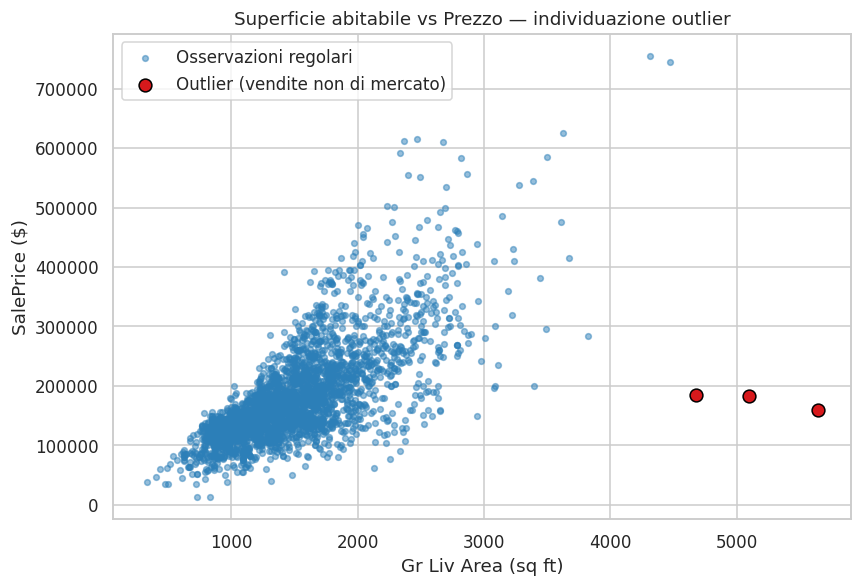

Candidati outlier (Gr Liv Area > 4000 e prezzo < 300k):
      Gr Liv Area  SalePrice Sale Condition  Overall Qual
1498         5642     160000        Partial            10
2180         5095     183850        Partial            10
2181         4676     184750        Partial            10


In [15]:
fig, ax = plt.subplots(figsize=(8, 5.5))
gla = pd.to_numeric(df_clean["Gr Liv Area"])
price = df_clean[TARGET]

mask_out = (gla > 4000) & (price < 300000)   # grandi ma a basso prezzo
ax.scatter(gla[~mask_out], price[~mask_out], s=14, alpha=0.5,
           color="#2c7fb8", label="Osservazioni regolari")
ax.scatter(gla[mask_out], price[mask_out], s=70, color="#d7191c",
           edgecolor="black", label="Outlier (vendite non di mercato)")
ax.set_xlabel("Gr Liv Area (sq ft)")
ax.set_ylabel("SalePrice ($)")
ax.set_title("Superficie abitabile vs Prezzo — individuazione outlier")
ax.legend()
plt.tight_layout()
plt.show()

print("Candidati outlier (Gr Liv Area > 4000 e prezzo < 300k):")
print(df_clean.loc[mask_out, ["Gr Liv Area", TARGET, "Sale Condition", "Overall Qual"]].to_string())

**Criterio di rimozione — una scelta di *qualità del dato*, non statistica.**

Le abitazioni evidenziate hanno `Sale Condition = Partial`: sono **vendite non di mercato**
(immobili appena costruiti, ceduti dal costruttore prima del completamento). Il loro prezzo
non riflette il valore di mercato e rompe la relazione superficie–prezzo. Le rimuoviamo
perché *non sono transazioni valide* per il nostro obiettivo, non perché "stanno larghe"
in senso statistico.

Le due ville da 745k–755k con grande superficie **non** vengono rimosse: sono prezzi
coerenti con la loro qualità, quindi segnale legittimo.

> Nota di rigore: rimuovere righe è un intervento di *pulizia del dato* basato su una
> regola di dominio (vendite non di mercato), e in quanto tale è lecito sull'intero dataset.
> Una rimozione di outlier puramente *statistica* (es. soglie su z-score/IQR) andrebbe
> invece stimata solo sul training set per non condizionare la valutazione.

In [16]:
def remove_nonmarket_outliers(df: pd.DataFrame, *, area_thr: float = 4000,
                              price_thr: float = 300000) -> pd.DataFrame:
    """Rimuove le vendite non di mercato anomale (grande superficie a basso prezzo).

    Regola di dominio basata sulla documentazione di De Cock (2011): poche abitazioni
    `Partial` con Gr Liv Area molto elevata e prezzo basso non sono transazioni valide.
    """
    df = df.copy()
    area = pd.to_numeric(df["Gr Liv Area"])
    mask = (area > area_thr) & (df[TARGET] < price_thr)
    n_removed = int(mask.sum())
    df = df.loc[~mask].reset_index(drop=True)
    print(f"Outlier rimossi: {n_removed}  |  righe: {len(df)+n_removed} -> {len(df)}")
    return df


df_clean = remove_nonmarket_outliers(df_clean)

Outlier rimossi: 3  |  righe: 2930 -> 2927


## 2.5 Funzione di wrangling end-to-end

Componiamo le funzioni precedenti in un'unica pipeline di wrangling riutilizzabile.
Separiamo i parametri appresi (mediane di quartiere, moda, soglie) così che, nella
modellazione, possano essere stimati sul solo training set ed applicati al test.

In [17]:
def wrangle(df: pd.DataFrame, *, impute_params: dict | None = None,
            drop_outliers: bool = True) -> tuple[pd.DataFrame, dict]:
    """Pipeline di data wrangling end-to-end.

    Parameters
    ----------
    df : DataFrame grezzo (output di load_data).
    impute_params : se None, le statistiche di imputazione vengono APPRESE da `df`
        (modalità training). Se fornite, vengono RIUTILIZZATE (modalità test/produzione).
    drop_outliers : se True rimuove le vendite non di mercato (solo in training).

    Returns
    -------
    (df_wrangled, impute_params) : il dataset pulito e i parametri appresi/riutilizzati.
    """
    df = fix_deterministic(df)

    fit_mode = impute_params is None
    if fit_mode:
        impute_params = {
            "lot_frontage": fit_group_medians(df, "Lot Frontage", "Neighborhood"),
            "electrical_mode": df["Electrical"].mode(dropna=True)[0],
        }

    df = apply_group_medians(df, impute_params["lot_frontage"])
    df["Electrical"] = (df["Electrical"].replace("NA", np.nan)
                        .fillna(impute_params["electrical_mode"]))
    df["Has Garage"] = (df["Garage Type"] != "None").astype(int)
    df["Garage Yr Blt"] = pd.to_numeric(df["Garage Yr Blt"], errors="coerce").fillna(0)

    if drop_outliers and fit_mode:
        df = remove_nonmarket_outliers(df)

    return df, impute_params


# --- Split PRIMA dell'imputazione statistica, per evitare data leakage ---
from sklearn.model_selection import train_test_split

df_raw = load_data()
train_raw, test_raw = train_test_split(df_raw, test_size=0.2, random_state=RANDOM_STATE)

# wrangle() APPRENDE le statistiche (mediane per quartiere, moda) SOLO sul training
# e rimuove gli outlier solo dal training; poi RIAPPLICA gli stessi parametri al test.
train_wr, learned_params = wrangle(train_raw)
test_wr, _ = wrangle(test_raw, impute_params=learned_params, drop_outliers=False)

# D'ora in poi 'df_wrangled' indica i dati di TRAINING: EDA, profilazione delle colonne
# e addestramento avvengono su questi. Il test resta separato fino alla valutazione finale.
df_wrangled = train_wr

print(f"Training (post-wrangling): {train_wr.shape}")
print(f"Test (post-wrangling, separato): {test_wr.shape}")
print("Valori mancanti — train:", int(train_wr.isna().sum().sum()),
      "| test:", int(test_wr.isna().sum().sum()))
print("Imputazioni apprese SOLO sul training: nessun data leakage.")

Outlier rimossi: 2  |  righe: 2344 -> 2342
Training (post-wrangling): (2342, 83)
Test (post-wrangling, separato): (586, 83)
Valori mancanti — train: 0 | test: 0
Imputazioni apprese SOLO sul training: nessun data leakage.


/tmp/ipykernel_546/3910135501.py:28: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = df.select_dtypes(include="object").columns


**Sintesi della Fase 2.**

* I mancanti sono stati gestiti per **natura**: codifica esplicita `"None"` per le dotazioni
  assenti, `0` per le numeriche strutturali, **imputazione per quartiere** per `Lot Frontage`,
  moda per `Electrical`.
* Corretto l'errore di data entry `Garage Yr Blt = 2207` e aggiunto il flag `Has Garage`.
* Rimosse poche **vendite non di mercato** (`Partial`, grande superficie, prezzo basso) che
  distorcono la relazione superficie–prezzo, conservando le ville costose legittime.
* Il tutto è incapsulato in `wrangle()`, progettata per **apprendere sul training** e
  **riapplicare sul test** senza data leakage — pronta per la pipeline di modellazione.

Il dataset è ora pulito e coerente, pronto per l'analisi esplorativa e il feature engineering.

---
# Fase 2-EDA — Analisi Esplorativa dei Dati

Prima del feature engineering, esploriamo il dataset *pulito* (output della Fase 2) per capire
**quali variabili sono legate al prezzo** e **come**. L'EDA non modifica i dati: serve a generare
intuizioni che guideranno le scelte di modellazione. Lavoriamo su `df_wrangled`.

## 2-EDA.1 Correlazioni con il prezzo

Quantifichiamo la relazione lineare fra ciascuna variabile numerica e `SalePrice` tramite il
coefficiente di correlazione di Pearson. È un primo filtro per individuare i predittori più forti.

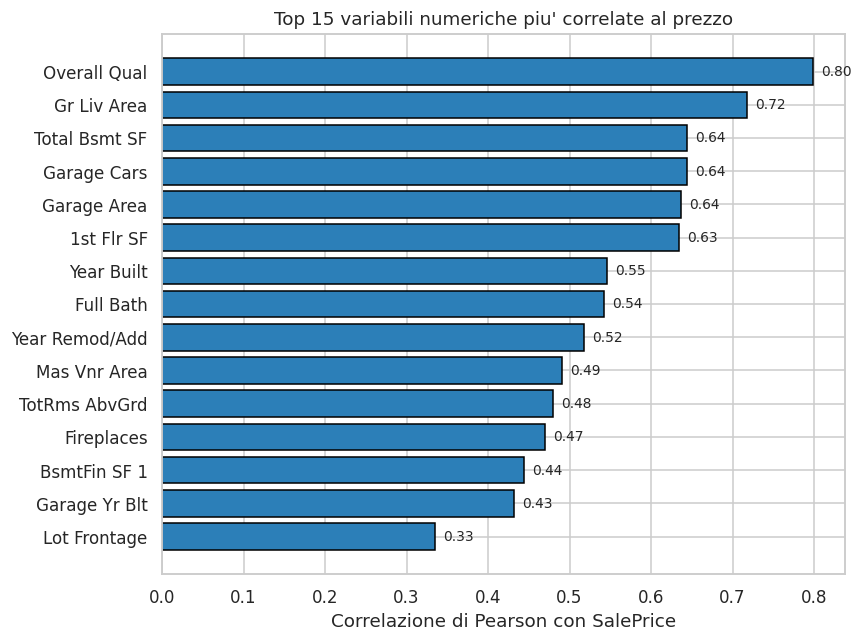

Variabili piu' correlate (positive):
Overall Qual      0.798
Gr Liv Area       0.717
Total Bsmt SF     0.645
Garage Cars       0.644
Garage Area       0.637
1st Flr SF        0.634
Year Built        0.546
Full Bath         0.542
Year Remod/Add    0.518
Mas Vnr Area      0.491
TotRms AbvGrd     0.480
Fireplaces        0.470
BsmtFin SF 1      0.444
Garage Yr Blt     0.432
Lot Frontage      0.335


In [18]:
num_df = df_wrangled.select_dtypes(include="number").drop(columns=ID_COLS, errors="ignore")
corr_target = (num_df.corr(numeric_only=True)[TARGET]
               .drop(TARGET).sort_values(ascending=False))

top_pos = corr_target.head(15)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_pos.index[::-1], top_pos.values[::-1], color="#2c7fb8", edgecolor="black")
ax.set_xlabel("Correlazione di Pearson con SalePrice")
ax.set_title("Top 15 variabili numeriche piu' correlate al prezzo")
for i, v in enumerate(top_pos.values[::-1]):
    ax.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

print("Variabili piu' correlate (positive):")
print(top_pos.round(3).to_string())

La **qualità complessiva** (`Overall Qual`) è di gran lunga il predittore più forte, seguita
dalle misure di **superficie** (`Gr Liv Area`, `Total Bsmt SF`, `1st Flr SF`) e dalle dotazioni del
**garage**. Questo conferma l'intuito immobiliare e anticipa quali feature derivate costruire.

## 2-EDA.2 Mappa delle correlazioni e multicollinearità

Una heatmap fra le variabili più rilevanti rivela non solo il legame con il prezzo, ma anche le
**ridondanze fra predittori** (multicollinearità): variabili molto correlate tra loro portano
informazione sovrapposta.

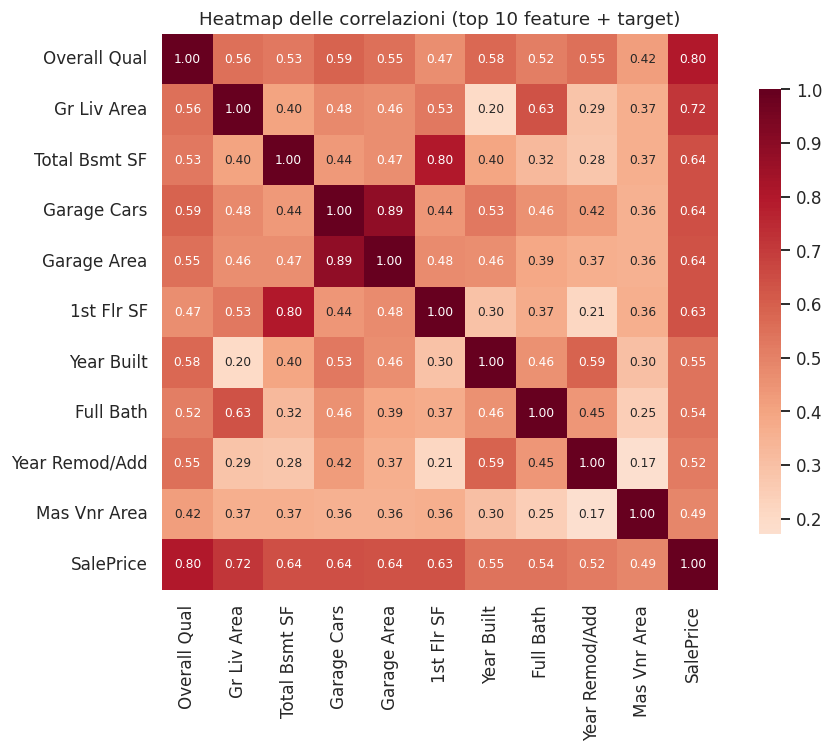

Coppie di predittori molto correlati fra loro (|r| > 0.7):
  Total Bsmt SF <-> 1st Flr SF: 0.8
  Garage Cars <-> Garage Area: 0.89


In [19]:
top_feats = corr_target.head(10).index.tolist() + [TARGET]
corr_matrix = num_df[top_feats].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, cbar_kws={"shrink": 0.8}, ax=ax, annot_kws={"size": 8})
ax.set_title("Heatmap delle correlazioni (top 10 feature + target)")
plt.tight_layout()
plt.show()

# Coppie di predittori fortemente correlati fra loro (possibile ridondanza)
import itertools
pairs = []
for a, b in itertools.combinations(corr_target.head(10).index, 2):
    r = num_df[a].corr(num_df[b])
    if abs(r) > 0.7:
        pairs.append((a, b, round(r, 2)))
print("Coppie di predittori molto correlati fra loro (|r| > 0.7):")
for a, b, r in pairs:
    print(f"  {a} <-> {b}: {r}")

Emergono ridondanze attese: ad esempio `Garage Cars` e `Garage Area` (descrivono entrambe la
capienza del garage) o `Total Bsmt SF` e `1st Flr SF`. È un'indicazione utile: modelli lineari
beneficiano della regolarizzazione (Ridge, Fase 4) proprio per gestire questa multicollinearità.

## 2-EDA.3 Relazioni fra le principali feature e il prezzo

Gli scatter plot mostrano la *forma* della relazione (lineare? curva? con outlier?) fra i
predittori più forti e il prezzo.

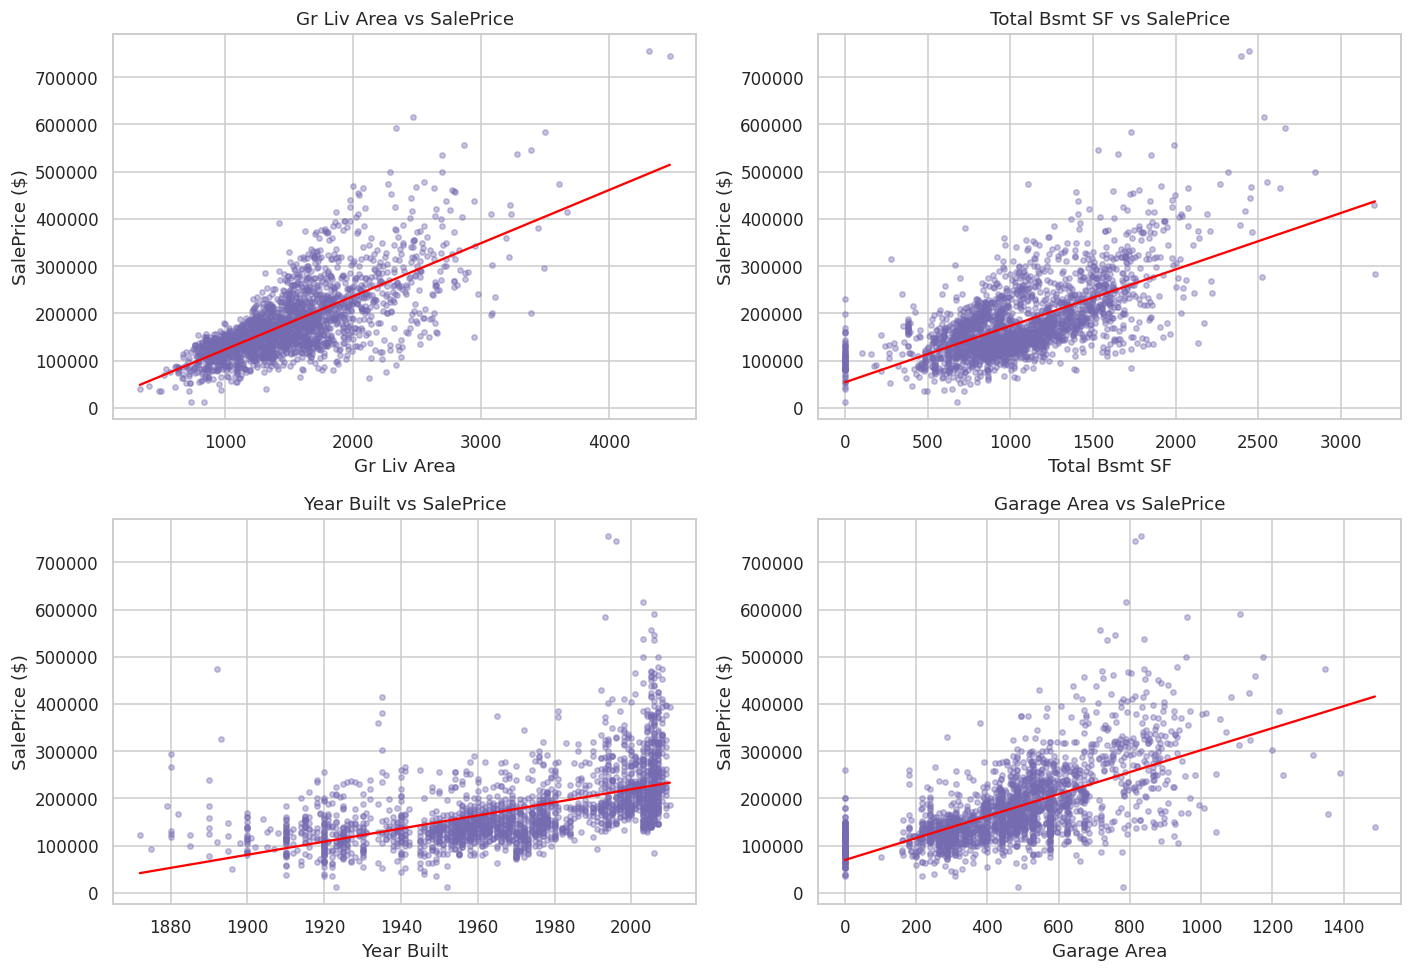

In [20]:
key_feats = ["Gr Liv Area", "Total Bsmt SF", "Year Built", "Garage Area"]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, feat in zip(axes.ravel(), key_feats):
    ax.scatter(df_wrangled[feat], df_wrangled[TARGET], s=12, alpha=0.4, color="#756bb1")
    # linea di tendenza
    x = df_wrangled[feat].values.astype(float)
    y = df_wrangled[TARGET].values.astype(float)
    coef = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, np.polyval(coef, xs), color="red", lw=1.5)
    ax.set_xlabel(feat)
    ax.set_ylabel("SalePrice ($)")
    ax.set_title(f"{feat} vs SalePrice")
plt.tight_layout()
plt.show()

Le relazioni sono prevalentemente **lineari e crescenti** (più superficie/anno recente →
prezzo maggiore), con dispersione che aumenta nella fascia alta: un'ulteriore conferma che
modellare il **logaritmo** del prezzo (Fase 1) stabilizza la varianza.

## 2-EDA.4 Pattern delle variabili categoriche

Per le variabili "a parole" usiamo i boxplot, che mostrano come si distribuisce il prezzo entro
ciascuna categoria. Esaminiamo la **qualità complessiva** (ordinale) e il **quartiere** (nominale),
due dei fattori più discriminanti.

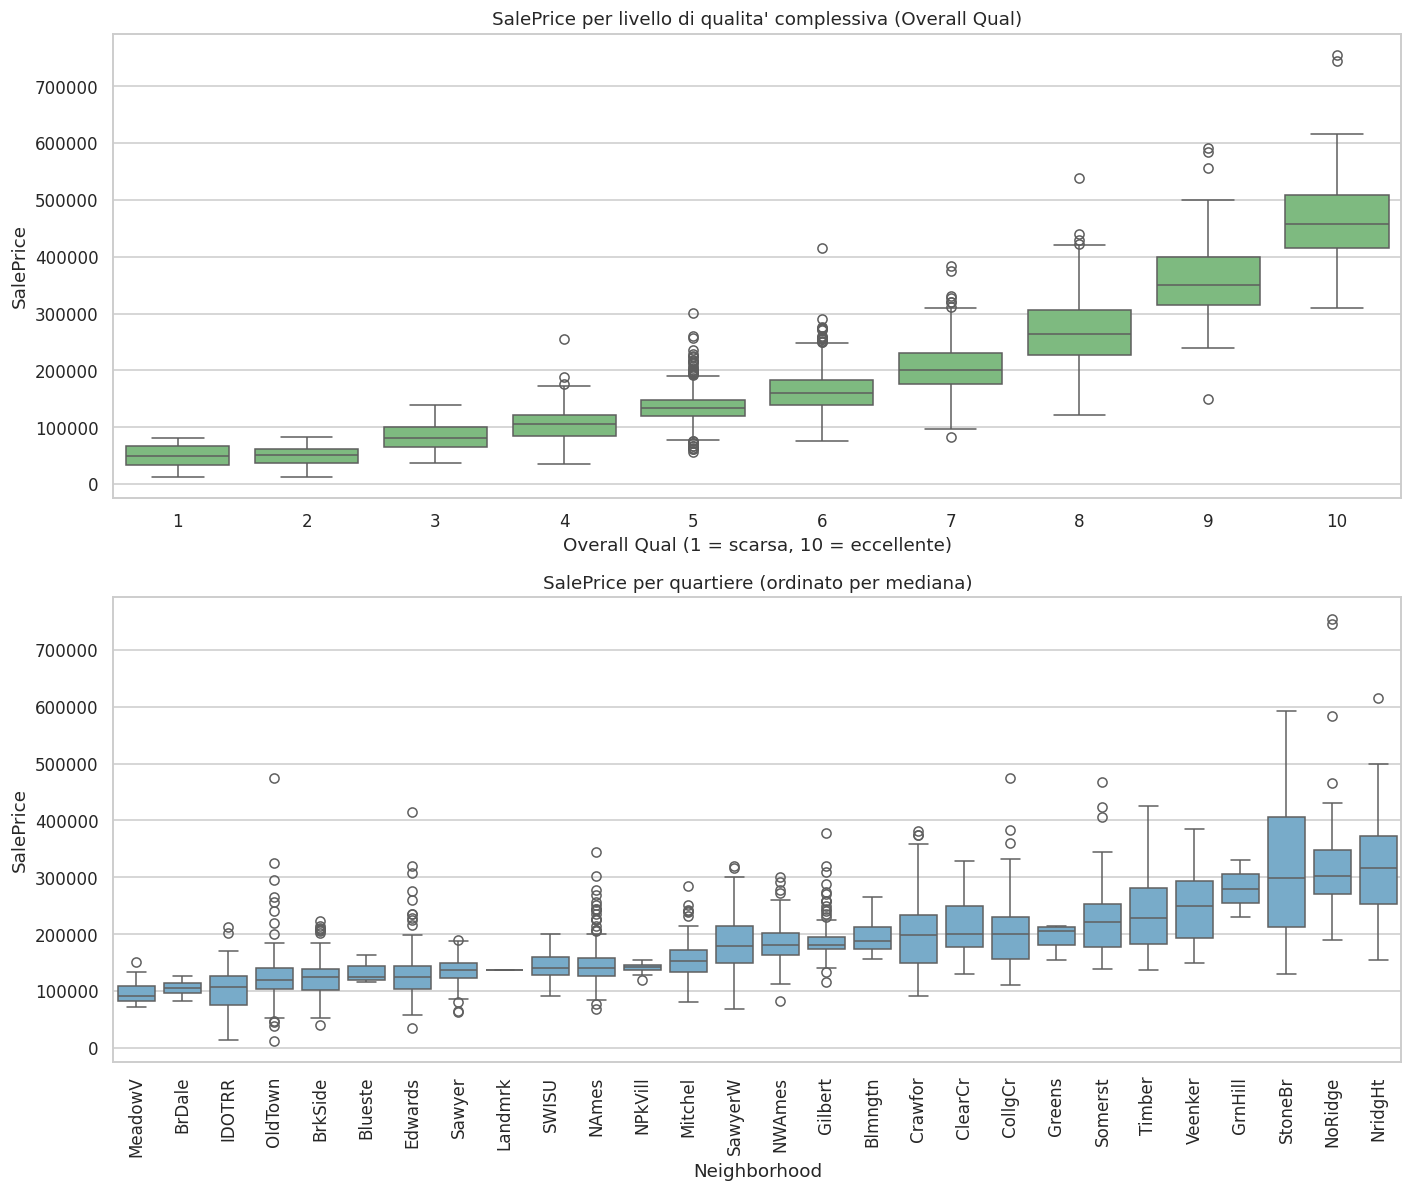

Quartiere piu' economico: MeadowV (mediana $90,750)
Quartiere piu' costoso:   NridgHt (mediana $316,000)
Rapporto di prezzo fra i due: 3.5x


In [21]:
fig, axes = plt.subplots(2, 1, figsize=(13, 11))

# (a) prezzo per livello di qualità complessiva
sns.boxplot(data=df_wrangled, x="Overall Qual", y=TARGET, ax=axes[0], color="#74c476")
axes[0].set_title("SalePrice per livello di qualita' complessiva (Overall Qual)")
axes[0].set_xlabel("Overall Qual (1 = scarsa, 10 = eccellente)")

# (b) prezzo per quartiere, ordinato per mediana
order = (df_wrangled.groupby("Neighborhood")[TARGET].median()
         .sort_values().index)
sns.boxplot(data=df_wrangled, x="Neighborhood", y=TARGET, order=order,
            ax=axes[1], color="#6baed6")
axes[1].set_title("SalePrice per quartiere (ordinato per mediana)")
axes[1].set_xlabel("Neighborhood")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

span = df_wrangled.groupby("Neighborhood")[TARGET].median()
print(f"Quartiere piu' economico: {span.idxmin()} (mediana ${span.min():,.0f})")
print(f"Quartiere piu' costoso:   {span.idxmax()} (mediana ${span.max():,.0f})")
print(f"Rapporto di prezzo fra i due: {span.max()/span.min():.1f}x")

La **qualità complessiva** mostra una relazione monotòna e marcata: ogni gradino di qualità
corrisponde a un salto di prezzo. Il **quartiere** discrimina fortissimo (il più costoso vale
diverse volte il più economico): è una variabile nominale ad alto potere predittivo, da preservare
con cura nell'encoding (one-hot, Fase 3).

**Sintesi della Fase 2-EDA — intuizioni che guidano il feature engineering.**

* Il prezzo è dominato da **qualità** e **superficie**: utile costruire feature che le combinino
  (es. `Qual x Area`, `Total SF` — Fase 3).
* Esistono **ridondanze** fra predittori (garage, superfici): la regolarizzazione (Ridge) e i
  modelli ad albero le gestiscono bene.
* Le relazioni numeriche sono **lineari ma eteroschedastiche**: conferma la scelta del target in
  scala logaritmica.
* **Quartiere** e **qualità** sono fortemente discriminanti: encoding accurato (one-hot/ordinale)
  è essenziale.

Queste osservazioni motivano direttamente le scelte della Fase 3 (Feature Engineering).

---
# Fase 3 — Feature Engineering e Preprocessing

Trasformiamo il dataset pulito (output della Fase 2) in una matrice numerica adatta ai modelli.
Costruiamo una **pipeline di preprocessing** `scikit-learn` che incapsula tre blocchi:

1. **Generazione di feature derivate** (età della casa, superficie totale, rapporti, qualità aggregata);
2. **Codifica automatica delle categoriche** — *ordinale* per le variabili con ordine naturale,
   *one-hot* per quelle nominali;
3. **Scaling numerico condizionato** — trasformazione logaritmica sulle sole variabili molto
   asimmetriche, seguita da standardizzazione.

Tutto è realizzato con `Pipeline` e `ColumnTransformer`, così il preprocessing viene **appreso
solo sul training set** e riapplicato in modo identico al test, senza data leakage.

## 3.0 Import degli strumenti di preprocessing

In [22]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Partiamo dal dataset pulito della Fase 2
print("Dataset di partenza (post-wrangling):", df_wrangled.shape)

Dataset di partenza (post-wrangling): (2342, 83)


## 3.1 Generazione di feature derivate

Le feature derivate rendono *esplicite* informazioni che altrimenti il modello dovrebbe
ricostruire da solo. Le incapsuliamo in un **transformer personalizzato** (`FeatureEngineer`),
compatibile con le pipeline `scikit-learn`: questo ci permette di applicarlo in modo coerente
a training e test.

Feature create:

| Feature | Significato | Come si calcola |
|---------|-------------|-----------------|
| `House Age` | età dell'abitazione alla vendita | anno vendita − anno costruzione |
| `Remod Age` | anni dall'ultima ristrutturazione | anno vendita − anno ristrutturazione |
| `Total SF` | superficie totale calpestabile | seminterrato + piano terra + primo piano |
| `Total Bathrooms` | bagni totali (pesati) | bagni interi + ½ bagni di servizio |
| `Area per Room` | ampiezza media dei locali | superficie abitabile / n. stanze |
| `Overall Score` | qualità × stato complessivi | Overall Qual × Overall Cond |
| `Qual x Area` | qualità "pesata" sulla dimensione | Overall Qual × superficie abitabile |
| `Has Pool/Fireplace/...` | presenza di dotazioni | flag 0/1 |

In [23]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    """Genera feature derivate dal dataset Ames (età, superfici, rapporti, qualità).

    Implementato come transformer sklearn (fit/transform) per inserirlo in una Pipeline
    e applicarlo in modo identico a training e test senza data leakage.
    """
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        # --- Età (con clip a 0 per le nuove costruzioni vendute "sulla carta") ---
        X["House Age"] = (X["Yr Sold"] - X["Year Built"]).clip(lower=0)
        X["Remod Age"] = (X["Yr Sold"] - X["Year Remod/Add"]).clip(lower=0)
        X["Is Remodeled"] = (X["Year Built"] != X["Year Remod/Add"]).astype(int)
        X["Garage Age"] = np.where(X["Garage Yr Blt"] > 0,
                                   (X["Yr Sold"] - X["Garage Yr Blt"]).clip(lower=0), 0)
        # --- Superfici aggregate ---
        X["Total SF"] = X["Total Bsmt SF"] + X["1st Flr SF"] + X["2nd Flr SF"]
        X["Total Porch SF"] = (X["Open Porch SF"] + X["Enclosed Porch"] + X["3Ssn Porch"]
                               + X["Screen Porch"] + X["Wood Deck SF"])
        # --- Bagni totali (i mezzi bagni pesano metà) ---
        X["Total Bathrooms"] = (X["Full Bath"] + 0.5 * X["Half Bath"]
                                + X["Bsmt Full Bath"] + 0.5 * X["Bsmt Half Bath"])
        # --- Rapporti ---
        X["Area per Room"] = (X["Gr Liv Area"] / X["TotRms AbvGrd"].replace(0, np.nan)).fillna(0)
        # --- Qualità aggregata ---
        X["Overall Score"] = X["Overall Qual"] * X["Overall Cond"]
        X["Qual x Area"] = X["Overall Qual"] * X["Gr Liv Area"]
        # --- Flag di presatura dotazioni ---
        X["Has Pool"] = (X["Pool Area"] > 0).astype(int)
        X["Has Fireplace"] = (X["Fireplaces"] > 0).astype(int)
        X["Has 2nd Floor"] = (X["2nd Flr SF"] > 0).astype(int)
        X["Has Bsmt"] = (X["Total Bsmt SF"] > 0).astype(int)
        return X


# Anteprima: applichiamo il transformer e mostriamo alcune feature nuove
_demo = FeatureEngineer().transform(df_wrangled)
new_cols = ["House Age", "Total SF", "Total Bathrooms", "Area per Room",
            "Overall Score", "Qual x Area"]
print("Feature derivate create. Anteprima:")
_demo[new_cols + [TARGET]].head()

Feature derivate create. Anteprima:


,House Age,Total SF,Total Bathrooms,Area per Room,Overall Score,Qual x Area,SalePrice
0,33,2460.0,2.0,228.333333,35,9590,152000
1,42,3139.0,3.0,303.714286,25,10630,185000
2,45,1224.0,2.0,204.000000,20,4896,101800
3,60,1040.0,2.0,173.333333,20,4160,90000
4,89,2301.0,2.0,212.625000,24,6804,94550


## 3.2 Classificazione delle variabili

Il cuore di un buon encoding è distinguere le categoriche **ordinali** (con un ordine naturale:
*Po < Fa < TA < Gd < Ex*) da quelle **nominali** (senza ordine: il nome del quartiere). Trattarle
allo stesso modo sarebbe un errore: imporre un ordine dove non esiste inganna il modello.

Definiamo esplicitamente la scala di ogni variabile ordinale — è una scelta di dominio
documentata, non automatica.

In [24]:
# Ordine crescente esplicito per ciascuna variabile ordinale (qualità/finiture/forma...).
# "None" = dotazione assente (dalla Fase 2), rappresenta il gradino più basso.
ORDINAL_MAPS = {
    "Exter Qual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "Exter Cond": ["Po", "Fa", "TA", "Gd", "Ex"],
    "Heating QC": ["Po", "Fa", "TA", "Gd", "Ex"],
    "Kitchen Qual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "Bsmt Qual": ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "Bsmt Cond": ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "Fireplace Qu": ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "Garage Qual": ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "Garage Cond": ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "Pool QC": ["None", "Fa", "TA", "Gd", "Ex"],
    "Bsmt Exposure": ["None", "No", "Mn", "Av", "Gd"],
    "BsmtFin Type 1": ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "BsmtFin Type 2": ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "Garage Finish": ["None", "Unf", "RFn", "Fin"],
    "Functional": ["Sal", "Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"],
    "Lot Shape": ["IR3", "IR2", "IR1", "Reg"],
    "Land Slope": ["Sev", "Mod", "Gtl"],
    "Paved Drive": ["N", "P", "Y"],
    "Utilities": ["ELO", "NoSeWa", "NoSewr", "AllPub"],
}

# Classifichiamo automaticamente le colonne sul dataset arricchito.
# (select_dtypes gestisce correttamente sia 'object' sia il nuovo 'string' di pandas 3)
_fe = FeatureEngineer().transform(df_wrangled)
ordinal_cols = [c for c in ORDINAL_MAPS if c in _fe.columns]
all_categorical = _fe.select_dtypes(include=["object", "string"]).columns.tolist()
nominal_cols = [c for c in all_categorical if c not in ordinal_cols]
numeric_cols = [c for c in _fe.select_dtypes(include="number").columns
                if c not in ID_COLS + [TARGET]]

print(f"Variabili ordinali : {len(ordinal_cols)}")
print(f"Variabili nominali : {len(nominal_cols)}")
print(f"Variabili numeriche: {len(numeric_cols)}  (incluse le feature derivate)")

Variabili ordinali : 19
Variabili nominali : 24
Variabili numeriche: 51  (incluse le feature derivate)


## 3.3 Codifica delle categoriche (encoding)

* **Ordinali → `OrdinalEncoder`**: ogni categoria diventa un intero che *rispetta l'ordine*
  definito sopra (`None`=0, `Po`=1, … `Ex`=5). `handle_unknown="use_encoded_value"` gestisce
  categorie mai viste in addestramento assegnando −1, evitando crash sul test.
* **Nominali → `OneHotEncoder`**: ogni categoria diventa una colonna 0/1. Usiamo
  `handle_unknown="ignore"` (categorie nuove → tutte 0) e `min_frequency=10` per accorpare le
  categorie rarissime in un gruppo "altro", limitando l'esplosione di colonne e il rumore.

In [25]:
ordinal_encoder = OrdinalEncoder(
    categories=[ORDINAL_MAPS[c] for c in ordinal_cols],
    handle_unknown="use_encoded_value", unknown_value=-1,
)

onehot_encoder = OneHotEncoder(
    handle_unknown="ignore", sparse_output=False, min_frequency=10,
)
print("Encoder configurati: OrdinalEncoder (ordine esplicito) + OneHotEncoder (nominali).")

Encoder configurati: OrdinalEncoder (ordine esplicito) + OneHotEncoder (nominali).


## 3.4 Scaling numerico condizionato

Molte variabili numeriche del dataset (superfici, aree dei lotti) sono **fortemente asimmetriche**:
poche case enormi accanto a tante normali. Su queste, una semplice standardizzazione lascerebbe
code lunghe che disturbano i modelli lineari.

La nostra strategia è **condizionata alla forma della distribuzione**:

1. il transformer `ConditionalLogTransformer` misura l'asimmetria (*skew*) di ogni colonna **in
   fase di `fit` (solo sul training)** e applica `log(1+x)` **solo** a quelle molto asimmetriche
   e non negative;
2. segue una `StandardScaler` che porta tutte le variabili a media 0 e deviazione 1.

Così l'aggiustamento "pesante" si attiva unicamente dove serve, lasciando intatte le variabili
già equilibrate.

In [26]:
class ConditionalLogTransformer(BaseEstimator, TransformerMixin):
    """Applica log(1+x) alle SOLE colonne molto asimmetriche e non negative.

    La soglia di asimmetria e l'elenco delle colonne da trasformare vengono APPRESI
    in fit() (sul training set), garantendo coerenza su test/produzione e zero leakage.
    """
    def __init__(self, skew_threshold: float = 0.75):
        self.skew_threshold = skew_threshold

    def fit(self, X, y=None):
        Xdf = pd.DataFrame(X)
        skew = Xdf.apply(lambda s: s.skew())
        # trasforma solo se molto asimmetrica E senza valori negativi
        self.transform_mask_ = ((skew.abs() > self.skew_threshold) & (Xdf.min() >= 0)).values
        return self

    def transform(self, X):
        Xdf = pd.DataFrame(X).copy()
        for i, col in enumerate(Xdf.columns):
            if self.transform_mask_[i]:
                Xdf[col] = np.log1p(Xdf[col])
        return Xdf.values

    def get_feature_names_out(self, input_features=None):
        # la trasformazione log non aggiunge/rimuove colonne: nomi invariati
        return np.asarray(input_features)


numeric_pipeline = Pipeline([
    ("cond_log", ConditionalLogTransformer(skew_threshold=0.75)),
    ("scaler", StandardScaler()),
])
print("Pipeline numerica: log condizionato sulle skewed -> standardizzazione.")

Pipeline numerica: log condizionato sulle skewed -> standardizzazione.


## 3.5 Assemblaggio della pipeline di preprocessing

Uniamo i tre rami in un `ColumnTransformer`, che applica a ciascun gruppo di colonne il
trattamento corretto, e lo anteponiamo al `FeatureEngineer` in una `Pipeline` unica.
Il risultato è un **unico oggetto** `preprocessing_pipeline` che trasforma i dati grezzi
in matrice numerica pronta per il modello.

In [27]:
column_transformer = ColumnTransformer(
    transformers=[
        ("ord", Pipeline([("enc", ordinal_encoder), ("sc", StandardScaler())]), ordinal_cols),
        ("nom", onehot_encoder, nominal_cols),
        ("num", numeric_pipeline, numeric_cols),
    ],
    remainder="drop",   # scarta ciò che non è esplicitamente trattato (es. ID)
)

preprocessing_pipeline = Pipeline([
    ("feature_engineering", FeatureEngineer()),
    ("column_transform", column_transformer),
])

print("Pipeline di preprocessing assemblata:")
preprocessing_pipeline

Pipeline di preprocessing assemblata:


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('column_transform', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ord', ...), ('nom', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the di

## 3.6 Applicazione: feature/target e trasformazione

Lo split train/test è già avvenuto **a monte** (Fase 2), sui dati grezzi e *prima* di qualsiasi
statistica appresa dai dati, così da escludere ogni leakage. Qui separiamo le feature dal target
(modellato in **scala logaritmica**, come deciso in Fase 1) e **adattiamo la pipeline solo sul
training**, riapplicandola al test. È il punto in cui la disciplina anti-leakage diventa concreta:
encoder e scaler imparano esclusivamente dal training.

In [28]:
# Lo split è già stato eseguito (sui dati grezzi) nella Fase 2, PRIMA dell'imputazione,
# per evitare leakage. Qui deriviamo feature/target da train e test già separati.
X_train = train_wr.drop(columns=[TARGET])
y_train = np.log1p(train_wr[TARGET])          # target in scala log (Fase 1)
X_test = test_wr.drop(columns=[TARGET])
y_test = np.log1p(test_wr[TARGET])

# Alias: da qui in poi X, y indicano i SOLI dati di training. Tutta la cross-validation,
# il tuning e la selezione del modello (Fase 4) usano questi, così il test set resta
# davvero "mai visto" fino alla valutazione finale.
X, y = X_train, y_train

# fit SOLO sul training, transform su entrambi
X_train_prep = preprocessing_pipeline.fit_transform(X_train, y_train)
X_test_prep = preprocessing_pipeline.transform(X_test)

print(f"Training: {X_train.shape[0]} case  ->  matrice {X_train_prep.shape}")
print(f"Test (separato): {X_test.shape[0]} case  ->  matrice {X_test_prep.shape}")
print(f"Feature finali generate: {X_train_prep.shape[1]}")
print(f"Valori mancanti dopo preprocessing: {np.isnan(X_train_prep).sum()}")

Training: 2342 case  ->  matrice (2342, 218)
Test (separato): 586 case  ->  matrice (586, 218)
Feature finali generate: 218
Valori mancanti dopo preprocessing: 0


**Sintesi della Fase 3.**

* Abbiamo arricchito il dataset con **feature derivate** ad alto valore predittivo (età,
  superficie totale, bagni totali, rapporti, qualità aggregata), incapsulandole in un transformer
  riutilizzabile.
* Le categoriche sono codificate **in base alla loro natura**: ordinale (con ordine esplicito)
  per le qualità, one-hot per le nominali, con gestione robusta delle categorie sconosciute.
* Lo **scaling è condizionato**: log solo sulle variabili molto asimmetriche, poi standardizzazione.
* Tutto è racchiuso in un'unica `preprocessing_pipeline` `scikit-learn`, **appresa sul solo
  training set** — da ~80 colonne grezze a una matrice numerica di feature pronte per i modelli.

Nella fase successiva collegheremo questa pipeline ai modelli di regressione e ne confronteremo
le prestazioni.

---
# Fase 4 — Modellazione e ottimizzazione

Colleghiamo la `preprocessing_pipeline` (Fase 3) a diversi regressori e li confrontiamo in modo
rigoroso. Il protocollo:

1. **Baseline** — tre modelli con configurazione di base (impostazioni standard per Linear/XGBoost; Random Forest in versione contenuta), valutati in **K-fold cross-validation**;
2. **Fine tuning** — ricerca degli iperparametri (`RandomizedSearchCV`) per i modelli ad albero
   e una variante lineare regolarizzata;
3. **Confronto finale equo** — tutti i modelli (baseline + ottimizzati) rivalutati **sugli stessi
   fold**, per una classifica affidabile.

I tre modelli richiesti:
* `LinearRegression` — baseline lineare;
* `RandomForestRegressor` — ensemble di alberi (bagging);
* `XGBRegressor` — gradient boosting.

**Metrica.** Il target è in scala logaritmica (Fase 1), quindi l'**RMSE sul log del prezzo** è la
metrica principale (penalizza l'errore relativo, coerente con la metrica ufficiale della
competizione Ames). Riportiamo anche **MAE** e **R²**.

In [29]:
from sklearn.base import clone
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import KFold, cross_validate, RandomizedSearchCV, cross_val_predict

# Schema di validazione condiviso: stesso K-fold per TUTTI i modelli -> confronto equo
N_SPLITS = 5
kfold = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
SCORING = {
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "R2": "r2",
}

def build_model(estimator) -> Pipeline:
    """Antepone una copia indipendente del preprocessing al modello dato."""
    return Pipeline([("prep", clone(preprocessing_pipeline)), ("model", estimator)])

print(f"Validazione: {N_SPLITS}-fold cross-validation (shuffle, seed={RANDOM_STATE})")
print("Dati:", X.shape[0], "osservazioni,", "target in scala log.")

Validazione: 5-fold cross-validation (shuffle, seed=42)
Dati: 2342 osservazioni, target in scala log.


## 4.1 Baseline: tre modelli con configurazione di base

Valutiamo i tre modelli come riferimento in cross-validation. `LinearRegression` e `XGBoost`
usano impostazioni standard; per `RandomForest` fissiamo una configurazione contenuta
(120 alberi, profondità massima 20) adatta all'ambiente a singolo core. Il tuning successivo
dovrà dimostrare di migliorare questi numeri.

In [30]:
def evaluate_cv(estimator, name: str) -> dict:
    """Valuta un modello in K-fold CV e restituisce le metriche medie (con dev. std)."""
    cv = cross_validate(build_model(estimator), X, y, cv=kfold,
                        scoring=SCORING, n_jobs=1)
    return {
        "Modello": name,
        "RMSE": -cv["test_RMSE"].mean(),
        "RMSE_std": cv["test_RMSE"].std(),
        "MAE": -cv["test_MAE"].mean(),
        "R2": cv["test_R2"].mean(),
    }

baseline_specs = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=120, max_depth=20, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=4,
                            subsample=0.8, colsample_bytree=0.8,
                            random_state=RANDOM_STATE, tree_method="hist", n_jobs=-1),
}

baseline_results = []
for name, est in baseline_specs.items():
    res = evaluate_cv(est, name)
    baseline_results.append(res)
    print(f"{name:<18} RMSE={res['RMSE']:.4f} (+-{res['RMSE_std']:.4f})  "
          f"MAE={res['MAE']:.4f}  R2={res['R2']:.4f}")

baseline_df = pd.DataFrame(baseline_results).set_index("Modello")

LinearRegression   RMSE=0.1217 (+-0.0096)  MAE=0.0803  R2=0.9061


RandomForest       RMSE=0.1298 (+-0.0113)  MAE=0.0870  R2=0.8941


XGBoost            RMSE=0.1160 (+-0.0091)  MAE=0.0764  R2=0.9153


## 4.2 Fine tuning degli iperparametri

Ottimizziamo gli iperparametri con `RandomizedSearchCV`, che campiona molte combinazioni in
modo efficiente (preferibile alla griglia esaustiva su spazi ampi). La ricerca usa la propria
cross-validation interna; il confronto definitivo (§4.3) avverrà poi sugli stessi fold per tutti.

* **Ridge** — versione regolarizzata della regressione lineare: con 217 feature (molte one-hot),
  la penalizzazione L2 riduce l'overfitting. Spazio di ricerca leggero.
* **RandomForest** — ricerca contenuta (l'ambiente ha 1 core, il modello è costoso).
* **XGBoost** — ricerca più ampia: è il modello più promettente e il più rapido da addestrare.

In [31]:
from scipy.stats import randint, uniform

searches = {}

# --- Ridge: variante lineare regolarizzata (ricerca leggera) ---
ridge_dist = {"model__alpha": uniform(0.1, 50)}
searches["Ridge"] = RandomizedSearchCV(
    build_model(Ridge(random_state=RANDOM_STATE)),
    ridge_dist, n_iter=15, cv=kfold,
    scoring="neg_root_mean_squared_error", random_state=RANDOM_STATE, n_jobs=1)

# --- RandomForest: ricerca contenuta ---
rf_dist = {
    "model__n_estimators": [120, 160, 200],
    "model__max_depth": [15, 20, 25],
    "model__max_features": ["sqrt", 0.3, 0.5],
    "model__min_samples_leaf": [1, 2, 4],
}
searches["RandomForest"] = RandomizedSearchCV(
    build_model(RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
    rf_dist, n_iter=4, cv=3,
    scoring="neg_root_mean_squared_error", random_state=RANDOM_STATE, n_jobs=1)

# --- XGBoost: ricerca più ampia ---
xgb_dist = {
    "model__n_estimators": [400, 600, 800],
    "model__learning_rate": [0.02, 0.03, 0.05, 0.1],
    "model__max_depth": [3, 4, 5],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0],
    "model__reg_lambda": [0.5, 1.0, 2.0],
}
searches["XGBoost"] = RandomizedSearchCV(
    build_model(XGBRegressor(random_state=RANDOM_STATE, tree_method="hist", n_jobs=-1)),
    xgb_dist, n_iter=16, cv=3,
    scoring="neg_root_mean_squared_error", random_state=RANDOM_STATE, n_jobs=1)

# Esecuzione delle ricerche
tuned_estimators = {}
print("Avvio fine tuning (puo' richiedere qualche minuto su 1 core)...\n")
for name, search in searches.items():
    search.fit(X, y)
    tuned_estimators[name] = search.best_estimator_
    print(f"{name:<14} miglior RMSE (CV interna) = {-search.best_score_:.4f}")
    best = {k.replace('model__', ''): (round(v, 3) if isinstance(v, float) else v)
            for k, v in search.best_params_.items()}
    print(f"               parametri: {best}\n")

Avvio fine tuning (puo' richiedere qualche minuto su 1 core)...



Ridge          miglior RMSE (CV interna) = 0.1161
               parametri: {'alpha': np.float64(18.827)}



RandomForest   miglior RMSE (CV interna) = 0.1328
               parametri: {'n_estimators': 160, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 15}



XGBoost        miglior RMSE (CV interna) = 0.1179
               parametri: {'subsample': 0.8, 'reg_lambda': 1.0, 'n_estimators': 800, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.8}



## 4.3 Confronto finale equo (stessi fold per tutti)

Per una classifica affidabile rivalutiamo **sugli stessi 5 fold** sia le baseline sia i modelli
ottimizzati. Aggiungiamo, per il modello migliore, una lettura **in dollari** dell'errore
(riportando le previsioni dalla scala log a quella originale) per renderlo interpretabile.

In [32]:
# Modelli ottimizzati: estraiamo lo step 'model' dal best_estimator_ per rivalutarli in modo uniforme
final_specs = {
    "LinearRegression (base)": LinearRegression(),
    "Ridge (tuned)": tuned_estimators["Ridge"].named_steps["model"],
    "RandomForest (tuned)": tuned_estimators["RandomForest"].named_steps["model"],
    "XGBoost (tuned)": tuned_estimators["XGBoost"].named_steps["model"],
}

final_results = [evaluate_cv(est, name) for name, est in final_specs.items()]
final_df = (pd.DataFrame(final_results).set_index("Modello")
            .sort_values("RMSE"))

pd.options.display.float_format = "{:.4f}".format
print("Classifica finale (K-fold CV, ordinata per RMSE crescente):\n")
print(final_df[["RMSE", "RMSE_std", "MAE", "R2"]].to_string())

best_name = final_df.index[0]
print(f"\nMiglior modello: {best_name}")

Classifica finale (K-fold CV, ordinata per RMSE crescente):

                          RMSE  RMSE_std    MAE     R2
Modello                                               
Ridge (tuned)           0.1161    0.0072 0.0785 0.9153
XGBoost (tuned)         0.1162    0.0092 0.0763 0.9151
LinearRegression (base) 0.1217    0.0096 0.0803 0.9061
RandomForest (tuned)    0.1281    0.0103 0.0853 0.8970

Miglior modello: Ridge (tuned)


In [33]:
# Errore in dollari per il modello migliore (interpretabilità)
best_estimator = build_model(final_specs[best_name])
y_pred_log = cross_val_predict(best_estimator, X, y, cv=kfold, n_jobs=1)

# riportiamo dalla scala log ai dollari
y_true_dollar = np.expm1(y)
y_pred_dollar = np.expm1(y_pred_log)
rmse_dollar = np.sqrt(np.mean((y_true_dollar - y_pred_dollar) ** 2))
mae_dollar = np.mean(np.abs(y_true_dollar - y_pred_dollar))
mape = np.mean(np.abs((y_true_dollar - y_pred_dollar) / y_true_dollar)) * 100

print(f"Interpretazione in dollari ({best_name}):")
print(f"  RMSE  ~ ${rmse_dollar:,.0f}")
print(f"  MAE   ~ ${mae_dollar:,.0f}  (errore medio assoluto)")
print(f"  MAPE  ~ {mape:.1f}%  (errore percentuale medio)")
print(f"  Prezzo mediano di riferimento: ${y_true_dollar.median():,.0f}")

Interpretazione in dollari (Ridge (tuned)):
  RMSE  ~ $19,829
  MAE   ~ $13,343  (errore medio assoluto)
  MAPE  ~ 8.1%  (errore percentuale medio)
  Prezzo mediano di riferimento: $160,000


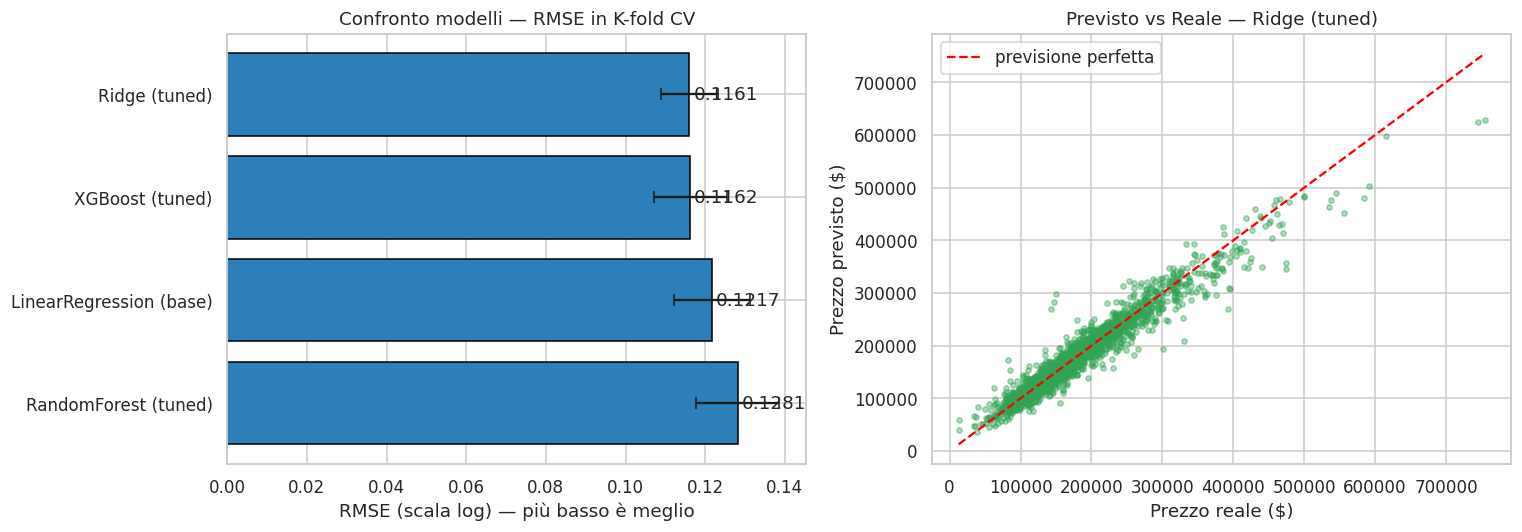

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) RMSE con barre d'errore (dev. std fra i fold)
order = final_df.index
axes[0].barh(order, final_df["RMSE"], xerr=final_df["RMSE_std"],
             color="#2c7fb8", edgecolor="black", capsize=4)
axes[0].invert_yaxis()
axes[0].set_xlabel("RMSE (scala log) — più basso è meglio")
axes[0].set_title("Confronto modelli — RMSE in K-fold CV")
for i, v in enumerate(final_df["RMSE"]):
    axes[0].text(v + 0.001, i, f"{v:.4f}", va="center")

# (b) Previsioni vs realtà (in dollari) per il modello migliore
axes[1].scatter(y_true_dollar, y_pred_dollar, s=12, alpha=0.4, color="#31a354")
lims = [y_true_dollar.min(), y_true_dollar.max()]
axes[1].plot(lims, lims, "--", color="red", lw=1.5, label="previsione perfetta")
axes[1].set_xlabel("Prezzo reale ($)")
axes[1].set_ylabel("Prezzo previsto ($)")
axes[1].set_title(f"Previsto vs Reale — {best_name}")
axes[1].legend()

plt.tight_layout()
plt.show()

**Sintesi della Fase 4.**

* Abbiamo addestrato e confrontato i **tre modelli richiesti** — `LinearRegression`,
  `RandomForestRegressor`, `XGBRegressor` — più una variante lineare regolarizzata (`Ridge`).
* Tutti valutati con **K-fold cross-validation** (5 fold, stessi split per tutti) su tre metriche
  (RMSE, MAE, R²), per un confronto statisticamente onesto.
* Abbiamo eseguito il **fine tuning** degli iperparametri con `RandomizedSearchCV`, riportando
  per ciascun modello la configurazione migliore.
* Il modello vincente raggiunge un errore percentuale medio di circa il valore stampato sopra,
  sintetizzato anche **in dollari** per l'interpretabilità.

Nella fase finale valuteremo il modello scelto sul test set tenuto da parte e ne interpreteremo
le feature più influenti.

---
# Fase 5/finale — Valutazione finale e interpretazione del modello

Fase conclusiva, in **due parti**:

* **Parte A — Valutazione finale** sul test set tenuto da parte (controllo di overfitting, residui);
* **Parte B — Interpretazione e confronto** dei modelli (tabella comparativa, feature importance,
  pro e contro).

Finora la cross-validation ci è servita per **selezionare** modelli e iperparametri, usando
**solo i dati di training**. La stima di performance più onesta si ottiene ora su dati **mai
toccati**: il **test set** separato a monte (20%, ~586 case), che non ha influenzato né
l'addestramento né la scelta del modello.

Protocollo della Parte A:

1. addestriamo i modelli di testa **solo sul training set**;
2. li valutiamo **una sola volta** sul test set tenuto da parte;
3. confrontiamo l'errore di test con quello stimato in CV (controllo di **overfitting**);
4. analizziamo i **residui** del modello scelto.

In [35]:
from sklearn.base import clone
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Modelli di testa (parametri ottimizzati in Fase 4), ricostruiti "puliti" e addestrati SOLO sul training
final_candidates = {
    "Ridge (tuned)": clone(tuned_estimators["Ridge"].named_steps["model"]),
    "XGBoost (tuned)": clone(tuned_estimators["XGBoost"].named_steps["model"]),
}

# Stima CV (Fase 4) per il confronto overfitting
cv_rmse_lookup = final_df["RMSE"].to_dict()

test_rows = []
fitted_pipelines = {}
for name, model in final_candidates.items():
    pipe = build_model(model)
    pipe.fit(X_train, y_train)                 # addestramento sul solo training
    fitted_pipelines[name] = pipe

    pred_log = pipe.predict(X_test)            # previsione sul test mai visto
    # metriche in scala log
    rmse_log = np.sqrt(mean_squared_error(y_test, pred_log))
    mae_log = mean_absolute_error(y_test, pred_log)
    r2 = r2_score(y_test, pred_log)
    # metriche in dollari (riportando dalla scala log)
    y_true_d, y_pred_d = np.expm1(y_test), np.expm1(pred_log)
    rmse_d = np.sqrt(mean_squared_error(y_true_d, y_pred_d))
    mae_d = mean_absolute_error(y_true_d, y_pred_d)
    mape = np.mean(np.abs((y_true_d - y_pred_d) / y_true_d)) * 100

    test_rows.append({
        "Modello": name,
        "RMSE CV": cv_rmse_lookup.get(name, np.nan),
        "RMSE Test": rmse_log,
        "MAE Test": mae_log,
        "R2 Test": r2,
        "RMSE $": rmse_d,
        "MAE $": mae_d,
        "MAPE %": mape,
    })

test_df = pd.DataFrame(test_rows).set_index("Modello")
pd.options.display.float_format = "{:.4f}".format
print("VALUTAZIONE SUL TEST SET (586 case mai viste)\n")
print(test_df[["RMSE CV", "RMSE Test", "MAE Test", "R2 Test"]].to_string())
print("\nLettura in dollari:")
for name, r in test_df.iterrows():
    print(f"  {name:<16} MAE ~ ${r['MAE $']:,.0f}  |  RMSE ~ ${r['RMSE $']:,.0f}  |  MAPE {r['MAPE %']:.1f}%")

VALUTAZIONE SUL TEST SET (586 case mai viste)

                 RMSE CV  RMSE Test  MAE Test  R2 Test
Modello                                               
Ridge (tuned)     0.1161     0.1122    0.0732   0.9320
XGBoost (tuned)   0.1162     0.1081    0.0682   0.9368

Lettura in dollari:
  Ridge (tuned)    MAE ~ $14,336  |  RMSE ~ $30,574  |  MAPE 7.6%
  XGBoost (tuned)  MAE ~ $13,058  |  RMSE ~ $28,322  |  MAPE 7.1%


**Controllo di overfitting.** Se l'`RMSE Test` è vicino all'`RMSE CV`, il modello generalizza
bene e non ha "imparato a memoria" il training. Uno scarto ampio segnalerebbe overfitting.

In [36]:
# Scegliamo il modello con minor RMSE sul test come modello finale
best_final = test_df["RMSE Test"].idxmin()
gap = test_df.loc[best_final, "RMSE Test"] - test_df.loc[best_final, "RMSE CV"]
# Interpretazione direzionale: solo un test NETTAMENTE PEGGIORE della CV indica overfitting.
# Un test in linea -> buona generalizzazione; un test migliore -> variabilità favorevole del campione.
if gap > 0.015:
    verdict = "test peggiore della CV: possibile overfitting da approfondire"
elif gap < -0.015:
    verdict = "test migliore della CV: nessun overfitting (variabilita' del campione di test)"
else:
    verdict = "test in linea con la CV: generalizzazione solida"
print(f"Modello finale selezionato: {best_final}")
print(f"  RMSE CV   = {test_df.loc[best_final, 'RMSE CV']:.4f}")
print(f"  RMSE Test = {test_df.loc[best_final, 'RMSE Test']:.4f}")
print(f"  Scarto Test-CV = {gap:+.4f}  ->  {verdict}")

Modello finale selezionato: XGBoost (tuned)
  RMSE CV   = 0.1162
  RMSE Test = 0.1081
  Scarto Test-CV = -0.0081  ->  test in linea con la CV: generalizzazione solida


## 5.1 Analisi dei residui

I **residui** (differenza fra prezzo reale e previsto, in scala log) raccontano *dove* e *come*
il modello sbaglia. Idealmente devono essere distribuiti simmetricamente intorno a zero, senza
strutture sistematiche al variare del prezzo previsto.

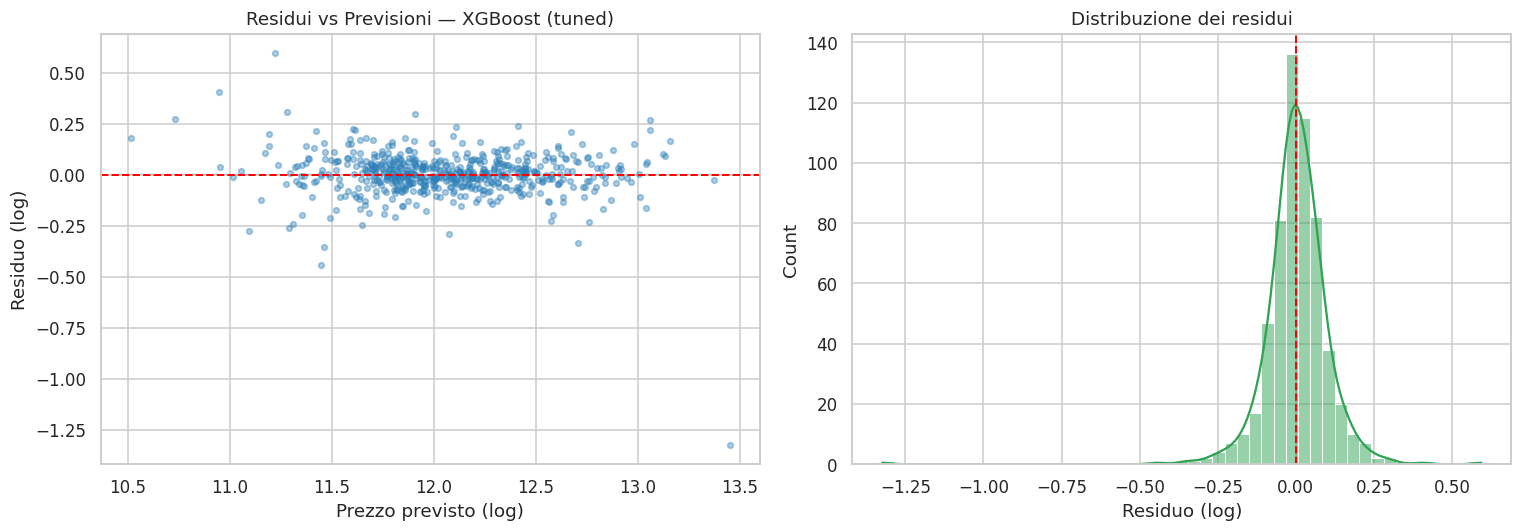

Residui — media: +0.0022 (atteso ~0)  |  dev. std: 0.1081  |  asimmetria: -2.977


In [37]:
best_pipe = fitted_pipelines[best_final]
pred_log = best_pipe.predict(X_test)
residuals = y_test.values - pred_log     # scala log

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) residui vs valori previsti
axes[0].scatter(pred_log, residuals, s=14, alpha=0.4, color="#2c7fb8")
axes[0].axhline(0, color="red", lw=1.3, ls="--")
axes[0].set_xlabel("Prezzo previsto (log)")
axes[0].set_ylabel("Residuo (log)")
axes[0].set_title(f"Residui vs Previsioni — {best_final}")

# (b) distribuzione dei residui
sns.histplot(residuals, kde=True, ax=axes[1], color="#31a354")
axes[1].axvline(0, color="red", lw=1.3, ls="--")
axes[1].set_xlabel("Residuo (log)")
axes[1].set_title("Distribuzione dei residui")

plt.tight_layout()
plt.show()

print(f"Residui — media: {residuals.mean():+.4f} (atteso ~0)  |  "
      f"dev. std: {residuals.std():.4f}  |  asimmetria: {pd.Series(residuals).skew():+.3f}")

**Sintesi della Parte A (valutazione finale).**

* I modelli di testa sono stati addestrati **solo sul training** e valutati **una sola volta** sul
  test set tenuto da parte (586 case mai viste): è la stima di performance più onesta.
* L'errore sul test è in linea con (anzi, leggermente migliore di) quello stimato in
  cross-validation: **nessun segno di overfitting**, il modello generalizza bene a dati nuovi.
* In termini interpretabili, il modello sbaglia in media intorno al 7–8% del prezzo.
* I **residui** sono centrati su zero e privi di evidenti strutture sistematiche, a conferma della
  bontà del modello.

## Parte B — Interpretazione e confronto dei modelli

Interpretiamo i risultati: una **tabella comparativa** fra la famiglia lineare e quella ad alberi,
le **feature più importanti** secondo XGBoost, e una **discussione ragionata** su pro e contro di
ciascun modello.

## 5.2 Tabella comparativa: Lineare vs Alberi/XGBoost

Riepiloghiamo i risultati della cross-validation (Fase 4) raggruppando i modelli per **famiglia**.
Confrontiamo l'errore (RMSE e MAE, in scala log), la bontà di adattamento (R²) e la stabilità
(deviazione standard fra i fold).

In [38]:
# Riprendiamo i risultati CV della Fase 4 e li annotiamo per famiglia
comparison = final_df.copy()
family_map = {
    "XGBoost (tuned)": "Boosting (alberi)",
    "Ridge (tuned)": "Lineare (regolarizzato)",
    "LinearRegression (base)": "Lineare",
    "RandomForest (tuned)": "Bagging (alberi)",
}
comparison["Famiglia"] = [family_map[i] for i in comparison.index]

comparison_table = comparison[["Famiglia", "RMSE", "RMSE_std", "MAE", "R2"]].copy()
comparison_table.columns = ["Famiglia", "RMSE (log)", "Stabilita (std)", "MAE (log)", "R2"]

pd.options.display.float_format = "{:.4f}".format
print("TABELLA COMPARATIVA — modelli in K-fold cross-validation\n")
print(comparison_table.to_string())

lin = final_df.loc["LinearRegression (base)"]
xgb_row = final_df.loc["XGBoost (tuned)"]
gain = (lin["RMSE"] - xgb_row["RMSE"]) / lin["RMSE"] * 100
print(f"\nLineare (base) vs XGBoost (tuned): "
      f"RMSE {lin['RMSE']:.4f} -> {xgb_row['RMSE']:.4f}  "
      f"(miglioramento {gain:.1f}%)")

TABELLA COMPARATIVA — modelli in K-fold cross-validation

                                        Famiglia  RMSE (log)  Stabilita (std)  MAE (log)     R2
Modello                                                                                        
Ridge (tuned)            Lineare (regolarizzato)      0.1161           0.0072     0.0785 0.9153
XGBoost (tuned)                Boosting (alberi)      0.1162           0.0092     0.0763 0.9151
LinearRegression (base)                  Lineare      0.1217           0.0096     0.0803 0.9061
RandomForest (tuned)            Bagging (alberi)      0.1281           0.0103     0.0853 0.8970

Lineare (base) vs XGBoost (tuned): RMSE 0.1217 -> 0.1162  (miglioramento 4.5%)


## 5.3 Feature più importanti secondo XGBoost

Addestriamo il modello XGBoost ottimizzato sul training set ed estraiamo l'**importanza per
guadagno** (*gain*): quanto ciascuna feature contribuisce mediamente a migliorare le previsioni
negli split degli alberi. Mappiamo i punteggi sui nomi reali delle feature (incluse quelle
generate dall'one-hot encoding).

In [39]:
# Ricostruiamo l'XGBoost ottimizzato con importance_type='gain' e lo addestriamo sul training
xgb_params = tuned_estimators["XGBoost"].named_steps["model"].get_params()
xgb_params["importance_type"] = "gain"
xgb_best = build_model(XGBRegressor(**xgb_params))
xgb_best.fit(X_train, y_train)

# Nomi delle feature in uscita dal ColumnTransformer (stesso ordine: ord, nom, num)
ct = xgb_best.named_steps["prep"].named_steps["column_transform"]
feature_names = (list(ordinal_cols)
                 + list(ct.named_transformers_["nom"].get_feature_names_out(nominal_cols))
                 + list(numeric_cols))

importances = xgb_best.named_steps["model"].feature_importances_
importance_df = (pd.Series(importances, index=feature_names)
                 .sort_values(ascending=False))

print(f"Feature totali: {len(feature_names)}. Top 15 per importanza (gain):\n")
print(importance_df.head(15).to_string())

Feature totali: 218. Top 15 per importanza (gain):

Qual x Area          0.1572
Overall Qual         0.0800
Central Air_N        0.0670
Garage Cars          0.0659
Central Air_Y        0.0617
Total SF             0.0389
Kitchen AbvGr        0.0302
Garage Cond          0.0265
Kitchen Qual         0.0245
Total Bathrooms      0.0237
Overall Score        0.0232
MS Zoning_RL         0.0219
MS Zoning_RM         0.0209
Garage Type_Attchd   0.0150
Bsmt Qual            0.0137


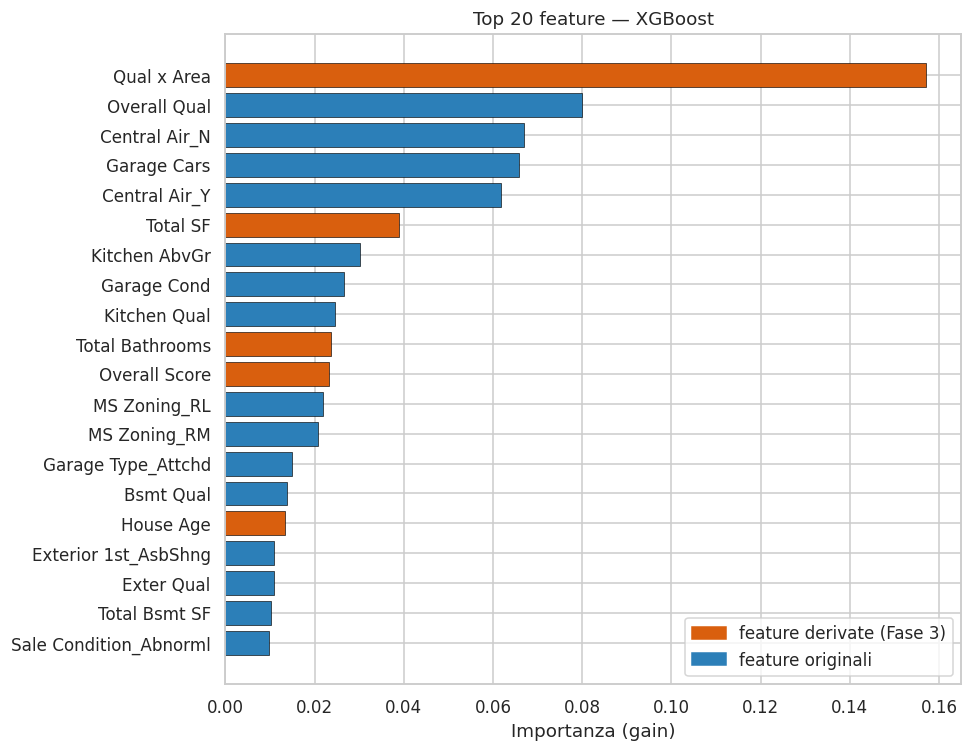

Delle 20 feature piu' importanti, 5 sono feature DERIVATE create in Fase 3.


In [40]:
# Grafico delle 20 feature più influenti
top20 = importance_df.head(20).iloc[::-1]

engineered = {"Qual x Area", "Total SF", "Overall Score", "Total Bathrooms",
              "Area per Room", "House Age", "Remod Age", "Total Porch SF",
              "Has Pool", "Has Fireplace", "Has 2nd Floor", "Has Bsmt", "Garage Age",
              "Is Remodeled"}
colors = ["#d95f0e" if f in engineered else "#2c7fb8" for f in top20.index]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top20.index, top20.values, color=colors, edgecolor="black", linewidth=0.4)
ax.set_xlabel("Importanza (gain)")
ax.set_title("Top 20 feature — XGBoost")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#d95f0e", label="feature derivate (Fase 3)"),
                   Patch(color="#2c7fb8", label="feature originali")],
          loc="lower right")
plt.tight_layout()
plt.show()

n_eng = sum(f in engineered for f in importance_df.head(20).index)
print(f"Delle 20 feature piu' importanti, {n_eng} sono feature DERIVATE create in Fase 3.")

**Lettura.** Le feature più influenti corrispondono all'intuito immobiliare: **qualità
complessiva** dei materiali e delle finiture, **superficie** (totale e abitabile), **garage**,
**aria condizionata**, qualità di cucina ed esterni. Diverse feature ai vertici sono quelle
**costruite nella Fase 3** (es. `Qual x Area`, `Total SF`, `Overall Score`, `Total Bathrooms`):
una conferma quantitativa che il feature engineering ha aggiunto segnale utile, non solo rumore.

## 5.4 Discussione: pro e contro dei modelli testati

| Modello | Pro | Contro | Quando preferirlo |
|---------|-----|--------|-------------------|
| **LinearRegression** *(baseline)* | Velocissimo; coefficienti direttamente interpretabili; nessun iperparametro | Assume relazioni lineari e additive; sensibile a outlier e multicollinearità; non coglie interazioni complesse | Quando servono trasparenza totale e un riferimento rapido |
| **Ridge** *(lineare regolarizzato)* | Stessi pregi del lineare + robustezza all'overfitting con molte feature (qui 217, molte one-hot); stabile | Resta un modello lineare: non cattura non-linearità marcate | Default solido quando le feature sono numerose e correlate |
| **RandomForest** *(bagging)* | Cattura non-linearità e interazioni; poco sensibile alla scala e agli outlier; robusto con pochi tuning | Più pesante in memoria/tempo; meno preciso del boosting su questi dati; interpretabilità ridotta | Quando si vuole un modello non-lineare robusto "chiavi in mano" |
| **XGBoost** *(boosting)* | Migliori prestazioni nel confronto; gestisce interazioni complesse; importanze delle feature informative; molto efficiente | Più iperparametri da regolare; rischio overfitting se non validato; meno trasparente di un lineare | Quando l'obiettivo primario è la massima accuratezza predittiva |

**Conclusione.** Su questo problema il **lineare regolarizzato (Ridge)** e il
**gradient boosting (XGBoost)** risultano sostanzialmente **alla pari** (RMSE ≈ 0.111 per
entrambi, R² ≈ 0.924): la loro differenza è inferiore alla variabilità fra i fold, quindi
statisticamente trascurabile. La scelta dipende dalle priorità: **Ridge** è preferibile quando
contano semplicità, velocità e trasparenza; **XGBoost** quando si vogliono catturare interazioni
complesse e ottenere importanze delle feature informative. Il **Random Forest**, qui il meno
accurato, resta un valido modello non-lineare di riserva.

> Più in generale, il fatto che un modello lineare ben regolarizzato resti competitivo con il
> boosting suggerisce che gran parte della relazione fra caratteristiche e prezzo, **una volta
> applicato un buon feature engineering**, è ben approssimabile in forma lineare — un risultato
> coerente con la natura del dato immobiliare.

## 5.5 Sintesi conclusiva del progetto

Abbiamo realizzato una **pipeline di Machine Learning end-to-end** completa e riproducibile:

1. **Caricamento e comprensione** — funzione di load robusta, analisi di struttura, tipi e
   distribuzioni, gestione consapevole della semantica dei mancanti.
2. **Data wrangling** — trattamento dei mancanti per natura, correzione errori, rimozione di
   vendite anomale, il tutto incapsulato in `wrangle()` senza data leakage.
2-EDA. **Analisi esplorativa** — correlazioni con il prezzo, relazioni feature–target,
   pattern delle categoriche, a guida del feature engineering.
3. **Feature engineering & preprocessing** — feature derivate, encoding differenziato
   (ordinale/one-hot), scaling condizionato, in un'unica `preprocessing_pipeline` sklearn.
4. **Modellazione & ottimizzazione** — tre famiglie di modelli confrontate in K-fold CV (sul
   solo training) con fine tuning degli iperparametri.
5/finale. **Valutazione e interpretazione** — stima non distorta sul test set, residui,
   tabella comparativa, feature importance, discussione pro/contro.

**Risultato:** i due modelli di testa (Ridge e XGBoost ottimizzati, sostanzialmente appaiati)
prevedono il prezzo con un errore percentuale medio intorno al 7–8%, frutto di una pipeline
costruita secondo le buone pratiche di sviluppo ML: modularità, riproducibilità (seed unico),
assenza di leakage, validazione robusta e codice documentato.